1. **ANALYSE DU DATASET**

ANALYSE DU DATASET PROFESSEUR

✅ Dataset trouvé : /kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images

📁 STRUCTURE DU DATASET
------------------------------------------------------------
📁 facesDataset/ (30571 items)
  📄 0000000.png (0.02 MB)
  📄 0000001.png (0.02 MB)
  📄 0000002.png (0.02 MB)
  📄 0000003.png (0.03 MB)
  📄 0000004.png (0.03 MB)
  📄 0000005.png (0.02 MB)
  📄 0000006.png (0.03 MB)
  📄 0000007.png (0.02 MB)
  📄 0000008.png (0.02 MB)
  📄 0000009.png (0.03 MB)
  📄 0000010.png (0.02 MB)
  📄 0000011.png (0.02 MB)
  📄 0000012.png (0.03 MB)
  📄 0000013.png (0.03 MB)
  📄 0000014.png (0.03 MB)
  📄 0000015.png (0.03 MB)
  📄 0000016.png (0.02 MB)
  📄 0000017.png (0.03 MB)
  📄 0000018.png (0.02 MB)
  📄 0000019.png (0.03 MB)
  ... et 30551 autres items
📁 facesDataset_masked/ (24678 items)
  📄 0000000_surgical_green.png (0.03 MB)
  📄 0000001_inpaint.png (0.03 MB)
  📄 0000002_empty.png (0.02 MB)
  📄 0000003_surgical_green.png (0.03 MB)
  📄 0000004_cloth.png (0.03 MB)
  📄 0000

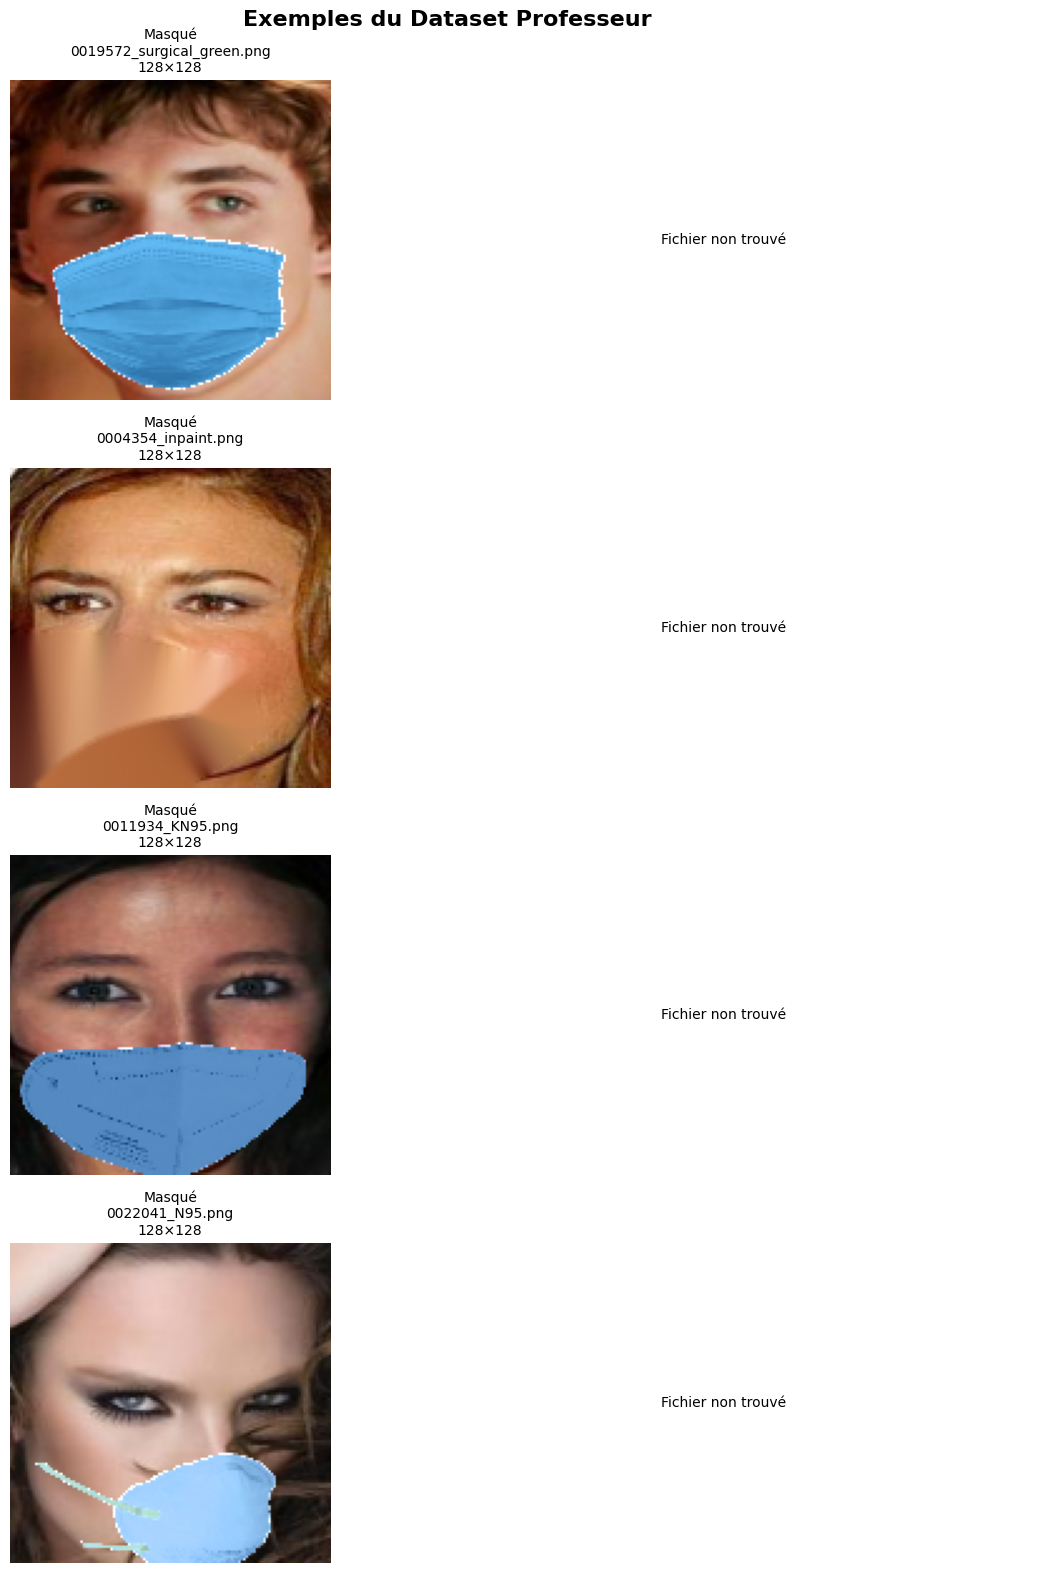

✅ Visualisation sauvegardée et affichée


📊 RECOMMANDATIONS

✅ Dataset analysé : 24678 paires détectées

⚠️  CORRECT mais peut être amélioré
   → Suffisant pour un premier entraînement
   → Possibilité d'ajouter CelebA si résultats < 27 PSNR

✅ DÉCISION : Commencer avec ce dataset
              Préparer CelebA en parallèle (optionnel)


📐 VÉRIFICATION DES DIMENSIONS REQUISES
------------------------------------------------------------
Dimensions actuelles :
  Masqué     : 128×128
  Non-masqué : 128×128

Dimensions requises :
  Input  : 32×32
  Target : 128×128

⚠️  RESIZE NÉCESSAIRE
   → Créer script de preprocessing
   → Voir 'preprocessing_script.py'

ANALYSE TERMINÉE

📝 Prochaines étapes :
1. ✅ Dataset analysé
2. Lire JDSR-GAN + Cheng EFBPGAN (2h)
3. Télécharger codes GitHub
4. Créer DataLoader PyTorch
5. Commencer l'implémentation !

💡 TIP KAGGLE :
   Activez GPU : Settings → Accelerator → GPU P100
   Cela sera nécessaire pour l'entraînement !


In [2]:
"""
SCRIPT D'ANALYSE DU DATASET - VERSION KAGGLE
À exécuter dans un notebook Kaggle
"""
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("="*60)
print("ANALYSE DU DATASET PROFESSEUR")
print("="*60)

# ============================================
# CONFIGURATION KAGGLE
# ============================================
DATASET_PATH = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images"

if not os.path.exists(DATASET_PATH):
    print(f"\n❌ Dataset introuvable : {DATASET_PATH}")
    print("\n💡 Vérifiez que vous avez bien ajouté le dataset dans votre notebook")
    print("   Settings → Add Data → Search 'masked celebahq cropped'")
    exit(1)

print(f"\n✅ Dataset trouvé : {DATASET_PATH}\n")

# ============================================
# 1. STRUCTURE DU DATASET
# ============================================
print("📁 STRUCTURE DU DATASET")
print("-" * 60)

def analyze_structure(path, level=0, max_level=2):
    """Analyse récursive de la structure"""
    if level > max_level:
        return
    
    try:
        items = sorted(os.listdir(path))
        for item in items[:20]:  # Afficher plus d'items
            item_path = os.path.join(path, item)
            indent = "  " * level
            
            if os.path.isdir(item_path):
                try:
                    num_files = len(os.listdir(item_path))
                    print(f"{indent}📁 {item}/ ({num_files} items)")
                    if level < max_level:
                        analyze_structure(item_path, level + 1, max_level)
                except:
                    print(f"{indent}📁 {item}/ (inaccessible)")
            else:
                size_mb = os.path.getsize(item_path) / (1024 * 1024)
                print(f"{indent}📄 {item} ({size_mb:.2f} MB)")
        
        if len(items) > 20:
            print(f"{indent}... et {len(items) - 20} autres items")
    except Exception as e:
        print(f"Erreur : {e}")

analyze_structure(DATASET_PATH)

# ============================================
# 2. TROUVER LES DOSSIERS IMAGES
# ============================================
print("\n\n🔍 RECHERCHE DES DOSSIERS D'IMAGES")
print("-" * 60)

def find_image_dirs(root_path):
    """Trouve tous les dossiers contenant des images"""
    image_dirs = {}
    
    for dirpath, dirnames, filenames in os.walk(root_path):
        # Compter les images dans ce dossier
        images = [f for f in filenames 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            rel_path = os.path.relpath(dirpath, root_path)
            image_dirs[rel_path] = len(images)
    
    return image_dirs

image_dirs = find_image_dirs(DATASET_PATH)

print("\nDossiers trouvés :")
for dir_name, count in sorted(image_dirs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {dir_name:50s} : {count:6d} images")

# ============================================
# 3. IDENTIFIER MASQUÉ vs NON-MASQUÉ
# ============================================
print("\n\n🎭 IDENTIFICATION MASQUÉ / NON-MASQUÉ")
print("-" * 60)

masked_dir = None
unmasked_dir = None

# Chercher avec différents patterns possibles
for dir_name in image_dirs.keys():
    dir_lower = dir_name.lower()
    
    # Patterns pour masqué
    if any(keyword in dir_lower for keyword in ['mask', 'masked', 'with_mask', 'withmask']):
        if not any(kw in dir_lower for kw in ['unmask', 'unmasked', 'without', 'clean']):
            masked_dir = dir_name
            print(f"✅ Trouvé MASQUÉ : {dir_name}")
    
    # Patterns pour non-masqué  
    if any(keyword in dir_lower for keyword in ['unmask', 'unmasked', 'without', 'clean', 'original', 'no_mask', 'nomask']):
        unmasked_dir = dir_name
        print(f"✅ Trouvé NON-MASQUÉ : {dir_name}")

# Si pas trouvé automatiquement, essayer des chemins probables
if not masked_dir or not unmasked_dir:
    print("\n⚠️  Détection automatique échouée, test des chemins standards...")
    
    possible_paths = [
        ('facesDataset_masked', 'facesDataset'),
        ('masked', 'unmasked'),
        ('with_mask', 'without_mask'),
        ('.', '.')  # Parfois les images sont directement dans le dossier root
    ]
    
    for mask_path, unmask_path in possible_paths:
        test_masked = os.path.join(DATASET_PATH, mask_path) if mask_path != '.' else DATASET_PATH
        test_unmasked = os.path.join(DATASET_PATH, unmask_path) if unmask_path != '.' else DATASET_PATH
        
        if os.path.exists(test_masked) and os.path.exists(test_unmasked):
            masked_files = [f for f in os.listdir(test_masked) if f.endswith(('.png', '.jpg'))]
            unmasked_files = [f for f in os.listdir(test_unmasked) if f.endswith(('.png', '.jpg'))]
            
            if masked_files and unmasked_files:
                masked_dir = mask_path
                unmasked_dir = unmask_path
                print(f"✅ Détecté : {mask_path} / {unmask_path}")
                break

if masked_dir:
    print(f"\n✅ Dossier MASQUÉ     : {masked_dir}")
    print(f"   → {image_dirs.get(masked_dir, 0)} images")
else:
    print(f"\n❌ Dossier MASQUÉ non trouvé")

if unmasked_dir:
    print(f"\n✅ Dossier NON-MASQUÉ : {unmasked_dir}")
    print(f"   → {image_dirs.get(unmasked_dir, 0)} images")
else:
    print(f"\n❌ Dossier NON-MASQUÉ non trouvé")

if not masked_dir or not unmasked_dir:
    print("\n⚠️  ATTENTION : Vérifiez manuellement la structure")
    print("Listez les dossiers disponibles ci-dessus")

# ============================================
# 4. ANALYSE DES DIMENSIONS
# ============================================
print("\n\n📐 ANALYSE DES DIMENSIONS")
print("-" * 60)

def analyze_dimensions(dir_path, sample_size=100):
    """Analyse les dimensions d'un échantillon"""
    if not dir_path:
        return None
        
    full_path = os.path.join(DATASET_PATH, dir_path) if dir_path != '.' else DATASET_PATH
    
    if not os.path.exists(full_path):
        return None
    
    images = [f for f in os.listdir(full_path) 
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not images:
        return None
    
    # Échantillonner
    sample = np.random.choice(images, min(sample_size, len(images)), replace=False)
    
    dimensions = []
    for img_name in sample:
        try:
            img_path = os.path.join(full_path, img_name)
            with Image.open(img_path) as img:
                dimensions.append(img.size)  # (width, height)
        except Exception as e:
            continue
    
    return dimensions

dims_masked = None
dims_unmasked = None

if masked_dir:
    print(f"\nImages MASQUÉES :")
    dims_masked = analyze_dimensions(masked_dir)
    if dims_masked:
        dim_counts = Counter(dims_masked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_masked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

if unmasked_dir:
    print(f"\nImages NON-MASQUÉES :")
    dims_unmasked = analyze_dimensions(unmasked_dir)
    if dims_unmasked:
        dim_counts = Counter(dims_unmasked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_unmasked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

# ============================================
# 5. VÉRIFIER SI PAIRES
# ============================================
print("\n\n🔗 VÉRIFICATION DES PAIRES")
print("-" * 60)

masked_files = []
unmasked_files = []

if masked_dir and unmasked_dir:
    masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
    unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
    
    masked_files = sorted([f for f in os.listdir(masked_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    unmasked_files = sorted([f for f in os.listdir(unmasked_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"\nNombre de fichiers masqués    : {len(masked_files)}")
    print(f"Nombre de fichiers non-masqués : {len(unmasked_files)}")
    
    # Comparer noms
    if len(masked_files) == len(unmasked_files):
        print("✅ Même nombre de fichiers")
        
        # Vérifier si noms correspondent
        if masked_files[:10] == unmasked_files[:10]:
            print("✅ Les noms de fichiers correspondent")
            print("\nExemples de paires :")
            for i in range(min(5, len(masked_files))):
                print(f"  {i+1}. {masked_files[i]}")
        else:
            print("⚠️  Les noms de fichiers NE correspondent PAS")
            print("\nMasqué (premiers 3)   :", masked_files[:3])
            print("Non-masqué (premiers 3):", unmasked_files[:3])
    else:
        print("⚠️  Nombre de fichiers DIFFÉRENT")
        diff = abs(len(masked_files) - len(unmasked_files))
        print(f"   Différence : {diff} fichiers")

# ============================================
# 6. VISUALISATION D'EXEMPLES  
# ============================================
print("\n\n📸 GÉNÉRATION DE VISUALISATIONS")
print("-" * 60)

if masked_dir and unmasked_dir and masked_files:
    try:
        masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
        unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
        
        # Prendre 4 exemples aléatoires
        sample_files = np.random.choice(masked_files, min(4, len(masked_files)), replace=False)
        
        fig, axes = plt.subplots(4, 2, figsize=(12, 16))
        fig.suptitle("Exemples du Dataset Professeur", fontsize=16, fontweight='bold')
        
        for i, filename in enumerate(sample_files):
            # Image masquée
            masked_img_path = os.path.join(masked_path, filename)
            try:
                masked_img = Image.open(masked_img_path)
                axes[i, 0].imshow(masked_img)
                axes[i, 0].set_title(f"Masqué\n{filename[:30]}\n{masked_img.size[0]}×{masked_img.size[1]}", 
                                    fontsize=10)
                axes[i, 0].axis('off')
            except Exception as e:
                axes[i, 0].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                              ha='center', va='center', fontsize=8)
                axes[i, 0].axis('off')
            
            # Image non-masquée
            unmasked_img_path = os.path.join(unmasked_path, filename)
            if os.path.exists(unmasked_img_path):
                try:
                    unmasked_img = Image.open(unmasked_img_path)
                    axes[i, 1].imshow(unmasked_img)
                    axes[i, 1].set_title(f"Non-masqué\n{filename[:30]}\n{unmasked_img.size[0]}×{unmasked_img.size[1]}", 
                                        fontsize=10)
                    axes[i, 1].axis('off')
                except Exception as e:
                    axes[i, 1].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                                  ha='center', va='center', fontsize=8)
                    axes[i, 1].axis('off')
            else:
                axes[i, 1].text(0.5, 0.5, "Fichier non trouvé", 
                              ha='center', va='center')
                axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig("dataset_prof_examples.png", dpi=150, bbox_inches='tight')
        plt.show()  # Afficher dans Kaggle
        print("✅ Visualisation sauvegardée et affichée")
        
    except Exception as e:
        print(f"❌ Erreur lors de la visualisation : {e}")
else:
    print("⚠️  Impossible de créer la visualisation")
    print("   Vérifiez que les dossiers sont correctement identifiés")

# ============================================
# 7. RECOMMANDATIONS
# ============================================
print("\n\n" + "="*60)
print("📊 RECOMMANDATIONS")
print("="*60)

total_pairs = min(len(masked_files), len(unmasked_files)) if masked_files and unmasked_files else 0

print(f"\n✅ Dataset analysé : {total_pairs} paires détectées")

if total_pairs >= 25000:
    print("\n🎉 EXCELLENT ! Dataset très large")
    print("   → Suffisant pour entraînement complet")
    print("   → PAS besoin de combiner avec d'autres datasets")
    print("\n✅ DÉCISION : Utiliser ce dataset tel quel")
    
elif total_pairs >= 15000:
    print("\n⚠️  CORRECT mais peut être amélioré")
    print("   → Suffisant pour un premier entraînement")
    print("   → Possibilité d'ajouter CelebA si résultats < 27 PSNR")
    print("\n✅ DÉCISION : Commencer avec ce dataset")
    print("              Préparer CelebA en parallèle (optionnel)")
    
elif total_pairs >= 5000:
    print("\n⚠️  PETIT - Combinaison recommandée")
    print("   → Risque d'overfitting")
    print("   → Recommandé : Ajouter 15-20k images de CelebA")
    print("\n✅ DÉCISION : Combiner avec CelebA")
    print(f"              Objectif : {total_pairs} + 15000 = ~{total_pairs + 15000} paires")
    
else:
    print("\n❌ TRÈS PETIT ou INTROUVABLE")
    if total_pairs == 0:
        print("   → Vérifiez la structure du dataset")
        print("   → Assurez-vous d'avoir ajouté le bon dataset dans Kaggle")
    else:
        print("   → Impossible d'entraîner un GAN avec < 5000 images")
        print("   → DOIT combiner avec CelebA")

# ============================================
# 8. VÉRIFIER DIMENSIONS REQUISES
# ============================================
if dims_masked and dims_unmasked:
    most_common_masked = Counter(dims_masked).most_common(1)[0][0]
    most_common_unmasked = Counter(dims_unmasked).most_common(1)[0][0]
    
    print(f"\n\n📐 VÉRIFICATION DES DIMENSIONS REQUISES")
    print("-" * 60)
    print(f"Dimensions actuelles :")
    print(f"  Masqué     : {most_common_masked[0]}×{most_common_masked[1]}")
    print(f"  Non-masqué : {most_common_unmasked[0]}×{most_common_unmasked[1]}")
    
    print(f"\nDimensions requises :")
    print(f"  Input  : 32×32")
    print(f"  Target : 128×128")
    
    need_resize = (most_common_masked != (32, 32) or 
                   most_common_unmasked != (128, 128))
    
    if need_resize:
        print(f"\n⚠️  RESIZE NÉCESSAIRE")
        print(f"   → Créer script de preprocessing")
        print(f"   → Voir 'preprocessing_script.py'")
    else:
        print(f"\n✅ DIMENSIONS CORRECTES")
        print(f"   → Dataset prêt à l'emploi !")

print("\n" + "="*60)
print("ANALYSE TERMINÉE")
print("="*60)

if total_pairs > 0:
    print("\n📝 Prochaines étapes :")
    print("1. ✅ Dataset analysé")
    print("2. Lire JDSR-GAN + Cheng EFBPGAN (2h)")
    print("3. Télécharger codes GitHub")
    print("4. Créer DataLoader PyTorch")
    print("5. Commencer l'implémentation !")
else:
    print("\n⚠️  Problème détecté :")
    print("1. Vérifiez que le dataset est bien ajouté dans Kaggle")
    print("2. Regardez la structure affichée ci-dessus")
    print("3. Ajustez les chemins si nécessaire")
    
print("\n💡 TIP KAGGLE :")
print("   Activez GPU : Settings → Accelerator → GPU P100")
print("   Cela sera nécessaire pour l'entraînement !")


**PREPROCESSING DATASET - Créer les bonnes dimensions32×32 masqué → 128×128 non-masqué**

In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil

print("="*60)
print("PREPROCESSING DATASET")
print("="*60)

# ============================================
# CONFIGURATION
# ============================================
INPUT_MASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset_masked"
INPUT_UNMASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset"

OUTPUT_DIR = "/kaggle/working/dataset_processed"

# Création dossiers
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "input_32"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "target_128"), exist_ok=True)

print(f"\n✅ Dossiers créés dans : {OUTPUT_DIR}\n")

# ============================================
# CRÉER LES PAIRES
# ============================================
print("🔍 Identification des paires...")

masked_files = sorted([f for f in os.listdir(INPUT_MASKED) if f.endswith('.png')])
pairs = []

for masked_file in masked_files:
    num_str = masked_file[:7]
    unmasked_file = f"{num_str}.png"
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    if os.path.exists(unmasked_path):
        pairs.append((masked_file, unmasked_file))

print(f"✅ {len(pairs)} paires trouvées\n")

# ============================================
# SPLIT TRAIN/VAL/TEST
# ============================================
np.random.seed(42)
np.random.shuffle(pairs)

n_train = int(len(pairs) * 0.8)
n_val = int(len(pairs) * 0.1)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print(f"📊 Split :")
print(f"  Train : {len(train_pairs)}")
print(f"  Val   : {len(val_pairs)}")
print(f"  Test  : {len(test_pairs)}\n")

# ============================================
# FONCTION DE TRAITEMENT
# ============================================
def process_pair(masked_file, unmasked_file, split_name, idx):

    masked_path = os.path.join(INPUT_MASKED, masked_file)
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    masked_img = cv2.imread(masked_path)
    unmasked_img = cv2.imread(unmasked_path)

    if masked_img is None:
        print(f"❌ Erreur lecture : {masked_path}")
        return False

    if unmasked_img is None:
        print(f"❌ Erreur lecture : {unmasked_path}")
        return False

    # Resize INPUT 32x32
    masked_32 = cv2.resize(masked_img, (32, 32), interpolation=cv2.INTER_CUBIC)

    # TARGET reste 128x128
    unmasked_128 = unmasked_img

    input_path = os.path.join(OUTPUT_DIR, split_name, "input_32", f"{idx:06d}.png")
    target_path = os.path.join(OUTPUT_DIR, split_name, "target_128", f"{idx:06d}.png")

    # Vérifier que l'écriture fonctionne
    ok1 = cv2.imwrite(input_path, masked_32)
    ok2 = cv2.imwrite(target_path, unmasked_128)

    if not ok1 or not ok2:
        print(f"❌ Erreur sauvegarde : {idx}")
        return False

    return True

# ============================================
# TRAITEMENT SPLITS
# ============================================
def process_split(pairs, split_name):

    print(f"\n🔄 Processing {split_name.upper()}...")
    success = 0

    for idx, (masked_file, unmasked_file) in enumerate(tqdm(pairs)):
        if process_pair(masked_file, unmasked_file, split_name, idx):
            success += 1

    print(f"✅ {split_name}: {success}/{len(pairs)} sauvegardées")
    return success


train_success = process_split(train_pairs, "train")
val_success = process_split(val_pairs, "val")
test_success = process_split(test_pairs, "test")

# ============================================
# RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("✅ PREPROCESSING TERMINÉ")
print("="*60)

total = train_success + val_success + test_success
print(f"\n📊 TOTAL sauvegardé : {total} images")

# ============================================
# VÉRIFICATION
# ============================================
if train_success > 0:
    example_input = cv2.imread(os.path.join(OUTPUT_DIR, "train/input_32/000000.png"))
    example_target = cv2.imread(os.path.join(OUTPUT_DIR, "train/target_128/000000.png"))

    print("\n🔎 Vérification dimensions :")
    print("Input  :", example_input.shape)
    print("Target :", example_target.shape)

# ============================================
# ZIP FINAL
# ============================================
print("\n📦 Compression en cours...")

zip_path = shutil.make_archive(
    os.path.join("/kaggle/working", "dataset_processed"),
    'zip',
    OUTPUT_DIR
)

print(f"✅ ZIP créé : {zip_path}")
print("Télécharge-le depuis l’onglet OUTPUT de Kaggle.")

PREPROCESSING DATASET

✅ Dossiers créés dans : /kaggle/working/dataset_processed

🔍 Identification des paires...
✅ 24678 paires trouvées

📊 Split :
  Train : 19742
  Val   : 2467
  Test  : 2469


🔄 Processing TRAIN...


100%|██████████| 19742/19742 [03:48<00:00, 86.58it/s]


✅ train: 19742/19742 sauvegardées

🔄 Processing VAL...


100%|██████████| 2467/2467 [00:29<00:00, 84.40it/s]


✅ val: 2467/2467 sauvegardées

🔄 Processing TEST...


100%|██████████| 2469/2469 [00:29<00:00, 84.29it/s]


✅ test: 2469/2469 sauvegardées

✅ PREPROCESSING TERMINÉ

📊 TOTAL sauvegardé : 24678 images

🔎 Vérification dimensions :
Input  : (32, 32, 3)
Target : (128, 128, 3)

📦 Compression en cours...
✅ ZIP créé : /kaggle/working/dataset_processed.zip
Télécharge-le depuis l’onglet OUTPUT de Kaggle.


**Vérifications et installations**

SETUP ENVIRONNEMENT KAGGLE

🔍 Vérification GPU...
PyTorch version : 2.9.0+cu126
CUDA disponible : True
CUDA version : 12.6
GPU name : Tesla T4
GPU memory : 15.64 GB
✅ GPU activé !

📦 Installation des packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00
✅ Packages installés

📚 Test des imports...
✅ Tous les imports fonctionnent

📁 Vérification du dataset...
Train inputs  : 19742 images
Train targets : 19742 images
✅ Dataset prêt !

🖼️  Test chargement d'une image...
Input shape  : (32, 32, 3)
Target shape : (128, 128, 3)


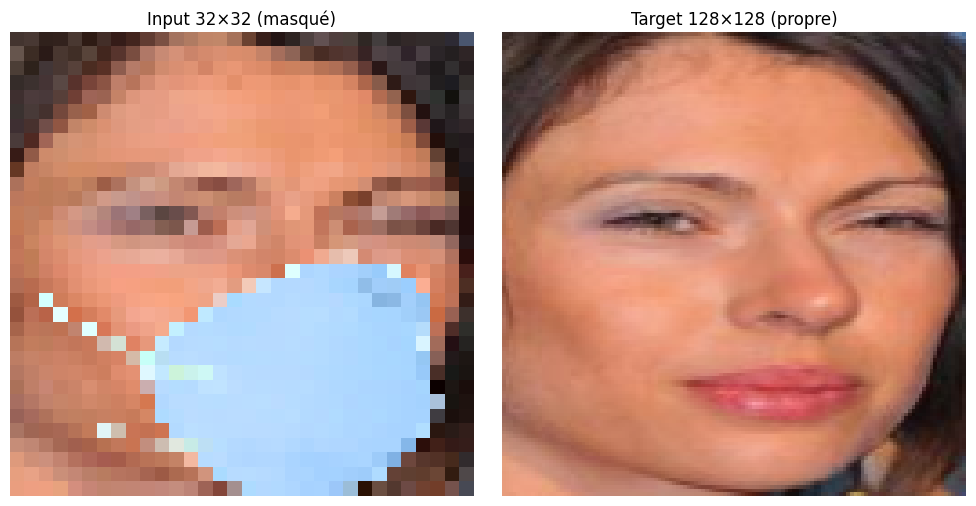


✅ Test réussi !

📊 RÉSUMÉ SETUP
✅ GPU : Activé
✅ PyTorch : 2.9.0+cu126
✅ Dataset : 19742 paires train
✅ Packages : opencv, lpips, timm, torchmetrics

🎯 Prêt pour l'implémentation !


In [4]:
"""
SETUP ENVIRONNEMENT - Vérifications et installations
"""

print("="*60)
print("SETUP ENVIRONNEMENT KAGGLE")
print("="*60)

# ============================================
# 1. VÉRIFIER GPU
# ============================================
print("\n🔍 Vérification GPU...")
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version : {torch.version.cuda}")
    print(f"GPU name : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("✅ GPU activé !")
else:
    print("❌ GPU non disponible")
    print("→ Aller dans Settings → Accelerator → GPU P100")

# ============================================
# 2. INSTALLER PACKAGES
# ============================================
print("\n📦 Installation des packages...")

!pip install -q opencv-python-headless
!pip install -q lpips  # Pour métrique perceptuelle
!pip install -q timm   # Pour certains backbones
!pip install -q torchmetrics  # Pour PSNR, SSIM

print("✅ Packages installés")

# ============================================
# 3. IMPORTS DE BASE
# ============================================
print("\n📚 Test des imports...")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import glob
from pathlib import Path

print("✅ Tous les imports fonctionnent")

# ============================================
# 4. VÉRIFIER DATASET
# ============================================
print("\n📁 Vérification du dataset...")

DATASET_PATH = "/kaggle/working/dataset_processed"

train_input_path = f"{DATASET_PATH}/train/input_32"
train_target_path = f"{DATASET_PATH}/train/target_128"

num_train_input = len(glob.glob(f"{train_input_path}/*.png"))
num_train_target = len(glob.glob(f"{train_target_path}/*.png"))

print(f"Train inputs  : {num_train_input} images")
print(f"Train targets : {num_train_target} images")

if num_train_input == num_train_target and num_train_input > 0:
    print("✅ Dataset prêt !")
else:
    print("❌ Problème avec le dataset")

# ============================================
# 5. TEST CHARGEMENT IMAGE
# ============================================
print("\n🖼️  Test chargement d'une image...")

# Charger une paire
input_img = cv2.imread(f"{train_input_path}/000000.png")
target_img = cv2.imread(f"{train_target_path}/000000.png")

print(f"Input shape  : {input_img.shape}")
print(f"Target shape : {target_img.shape}")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input 32×32 (masqué)")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Target 128×128 (propre)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Test réussi !")

# ============================================
# 6. RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("📊 RÉSUMÉ SETUP")
print("="*60)
print(f"✅ GPU : {'Activé' if torch.cuda.is_available() else 'Non activé'}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ Dataset : {num_train_input} paires train")
print(f"✅ Packages : opencv, lpips, timm, torchmetrics")
print("\n🎯 Prêt pour l'implémentation !")



**verification  que GPU est activé**

In [5]:
import torch

print("="*60)
print("VÉRIFICATION GPU")
print("="*60)

if torch.cuda.is_available():
    print("✅ GPU ACTIVÉ")
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"Mémoire : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU NON ACTIVÉ")
    print("→ Settings → Accelerator → GPU P100")

VÉRIFICATION GPU
✅ GPU ACTIVÉ
GPU : Tesla T4
Mémoire : 15.64 GB


**DATALOADER PYTORCH - MEFSR-GANPour charger les paires 32×32 → 128×128**

In [6]:
%%writefile /kaggle/working/create_dataloader.py
"""
DATALOADER PYTORCH - MEFSR-GAN avec data augmentation
"""

import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pathlib import Path
import glob
import random

class FaceSRDataset(Dataset):
    """
    Dataset avec option d'augmentation pour l'entraînement.
    """
    def __init__(self, data_root, train=True):
        self.data_root = Path(data_root)
        self.train = train
        self.input_files = sorted(glob.glob(str(self.data_root / "input_32" / "*.png")))
        self.target_files = sorted(glob.glob(str(self.data_root / "target_128" / "*.png")))
        assert len(self.input_files) == len(self.target_files), \
            f"Mismatch: {len(self.input_files)} inputs vs {len(self.target_files)} targets"

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self, idx):
        # Chargement des images
        input_img = cv2.imread(self.input_files[idx])
        target_img = cv2.imread(self.target_files[idx])

        # BGR → RGB
        input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)

        # Normalisation [0, 255] → [0, 1]
        input_img = input_img.astype(np.float32) / 255.0
        target_img = target_img.astype(np.float32) / 255.0

        # Conversion en tenseurs (C, H, W)
        input_tensor = torch.from_numpy(input_img).permute(2, 0, 1)
        target_tensor = torch.from_numpy(target_img).permute(2, 0, 1)

        # Data augmentation (uniquement pour l'entraînement)
        if self.train:
            # Random horizontal flip (même pour les deux images)
            if random.random() > 0.5:
                input_tensor = torch.flip(input_tensor, dims=[2])
                target_tensor = torch.flip(target_tensor, dims=[2])

            # Vous pouvez ajouter d'autres augmentations ici si vous le souhaitez
            # (attention à les appliquer de manière cohérente aux deux images)

        return input_tensor, target_tensor

def create_dataloaders(dataset_root, batch_size=16, num_workers=2):
    """
    Crée les DataLoaders train/val/test avec augmentation pour le train.
    """
    train_root = Path(dataset_root) / "train"
    val_root = Path(dataset_root) / "val"
    test_root = Path(dataset_root) / "test"

    train_dataset = FaceSRDataset(train_root, train=True)
    val_dataset = FaceSRDataset(val_root, train=False)
    test_dataset = FaceSRDataset(test_root, train=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    return train_loader, val_loader, test_loader

Writing /kaggle/working/create_dataloader.py


1. **MODULE 1 : MASK REMOVAL**

In [7]:
%%writefile /kaggle/working/module1_mask_removal.py
"""
MODULE 1 : MASK REMOVAL
Inspiré de JDSR-GAN (2023)
IDENTIQUE pour toutes les versions

Input : [B, 3, 32, 32] (visage masqué LR)
Output : [B, 64, 32, 32] (features débruitées)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    """Bloc résiduel de base avec skip connection"""
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual  # Skip connection
        out = self.relu(out)
        return out


class MaskRemovalModule(nn.Module):
    """
    Module de débruitage pour enlever le masque facial
    """
    
    def __init__(self, in_channels=3, out_channels=64, num_residual_blocks=4):
        super(MaskRemovalModule, self).__init__()
        
        # Encoder
        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Résidual blocks
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(64) for _ in range(num_residual_blocks)
        ])
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        features = self.initial_conv(x)
        for res_block in self.residual_blocks:
            features = res_block(features)
        features = self.decoder(features)
        return features

Writing /kaggle/working/module1_mask_removal.py


**2. MODULE 2 : EDGE FUSION + attention**

In [8]:
%%writefile /kaggle/working/module2_edge_fusion.py
"""
MODULE 2 : EDGE FUSION AVEC ATTENTION
Inspiré de Cheng EFBPGAN (2024)

Input : [B, 64, 32, 32] features + [B, 1, 32, 32] edges
Output : [B, 64, 32, 32] features enrichies
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np


# ============================================
# EXTRACTION EDGES (CANNY)
# ============================================
def extract_edges_canny(images, low_threshold=50, high_threshold=150):
    """
    Extrait les contours via l'algorithme de Canny
    """
    batch_size, _, H, W = images.shape
    device = images.device
    
    edges_batch = []
    
    for i in range(batch_size):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img * 255).astype(np.uint8)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, low_threshold, high_threshold)
        edges = edges.astype(np.float32) / 255.0
        edges_batch.append(edges)
    
    edges_batch = np.stack(edges_batch, axis=0)
    edges_tensor = torch.from_numpy(edges_batch).unsqueeze(1)
    
    return edges_tensor.to(device)


# ============================================
# ATTENTION MODULES
# ============================================
class ChannelAttention(nn.Module):
    """Channel Attention Module"""
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)


class EdgeFusionAttention(nn.Module):
    """
    Version 2.0 : Fusion avec Attention (Channel + Spatial)
    """
    
    def __init__(self, feature_channels=64):
        super(EdgeFusionAttention, self).__init__()
        
        # Attention modules
        self.channel_attn = ChannelAttention(feature_channels)
        self.spatial_attn = SpatialAttention()
        
        # Fusion finale
        self.fusion = nn.Sequential(
            nn.Conv2d(feature_channels + 1, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(feature_channels, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, features, edges):
        """
        Args:
            features : [B, 64, 32, 32] features du Module 1
            edges : [B, 1, 32, 32] edges extraits par Canny
        
        Returns:
            fused : [B, 64, 32, 32] features enrichies avec attention
        """
        # Channel Attention sur features
        ca_weight = self.channel_attn(features)  # [B, 64, 1, 1]
        features_ca = features * ca_weight  # [B, 64, 32, 32]
        
        # Spatial Attention guidée par edges
        sa_weight = self.spatial_attn(edges)  # [B, 1, 32, 32]
        features_sa = features_ca * sa_weight  # [B, 64, 32, 32]
        
        # Concat avec edges
        combined = torch.cat([features_sa, edges], dim=1)  # [B, 65, 32, 32]
        
        # Fusion
        fused = self.fusion(combined)  # [B, 64, 32, 32]
        
        return fused

Writing /kaggle/working/module2_edge_fusion.py


3. **MODULE 3 : SR NETWORK AVEC ESRGAN**

In [9]:
%%writefile /kaggle/working/module3_sr_network.py
"""
MODULE 3 : SR NETWORK AVEC ESRGAN
Architecture RRDB (Residual in Residual Dense Block)

Input : [B, 64, 32, 32]
Output : [B, 3, 128, 128] (facteur ×4)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================
# UPSAMPLING BLOCK
# ============================================
class UpsampleBlock(nn.Module):
    """Upsampling block (×2) avec PixelShuffle"""
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.prelu = nn.PReLU()
    
    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.prelu(x)
        return x


# ============================================
# ESRGAN RRDB BLOCKS
# ============================================
class DenseBlock(nn.Module):
    """Dense block pour RRDB"""
    def __init__(self, channels, growth_channels=32):
        super(DenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, growth_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3*growth_channels, growth_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4*growth_channels, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.beta = 0.2  # Résidual scaling
    
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], dim=1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], dim=1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], dim=1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], dim=1))
        return x5 * self.beta + x


class RRDB(nn.Module):
    """Residual in Residual Dense Block"""
    def __init__(self, channels, growth_channels=32):
        super(RRDB, self).__init__()
        self.dense1 = DenseBlock(channels, growth_channels)
        self.dense2 = DenseBlock(channels, growth_channels)
        self.dense3 = DenseBlock(channels, growth_channels)
        self.beta = 0.2
    
    def forward(self, x):
        out = self.dense1(x)
        out = self.dense2(out)
        out = self.dense3(out)
        return out * self.beta + x


class SRNetworkESRGAN(nn.Module):
    """
    Version 2.0 : SR Network avec RRDB (ESRGAN)
    Plus puissant que ResNet simple
    """
    
    def __init__(self, in_channels=64, out_channels=3, num_rrdb_blocks=12):
        super(SRNetworkESRGAN, self).__init__()
        
        # Initial conv
        self.conv_first = nn.Conv2d(in_channels, 64, 3, padding=1)
        
        # RRDB blocks
        self.rrdb_blocks = nn.ModuleList([
            RRDB(64, growth_channels=32) for _ in range(num_rrdb_blocks)
        ])
        
        # Conv après RRDB
        self.conv_body = nn.Conv2d(64, 64, 3, padding=1)
        
        # Upsampling ×4 (2 blocs ×2)
        self.upsample1 = UpsampleBlock(64, scale_factor=2)  # 32 → 64
        self.upsample2 = UpsampleBlock(64, scale_factor=2)  # 64 → 128
        
        # Conv finale
        self.conv_hr = nn.Conv2d(64, 64, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.conv_last = nn.Conv2d(64, out_channels, 3, padding=1)
    
    def forward(self, x):
        """
        Args:
            x : [B, 64, 32, 32] features enrichies
        
        Returns:
            out : [B, 3, 128, 128] image HR
        """
        feat = self.conv_first(x)
        trunk = feat
        
        # RRDB processing
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        
        trunk = self.conv_body(trunk)
        feat = feat + trunk  # Long skip connection
        
        # Upsampling
        feat = self.upsample1(feat)  # [B, 64, 64, 64]
        feat = self.upsample2(feat)  # [B, 64, 128, 128]
        
        # Output RGB
        out = self.conv_hr(feat)
        out = self.lrelu(out)
        out = self.conv_last(out)  # [B, 3, 128, 128]
        
        return out

Writing /kaggle/working/module3_sr_network.py


**4. MEFSR-GAN VERSION**

In [10]:
%%writefile /kaggle/working/mefsr_gan_v2.py
"""
MEFSR-GAN VERSION 2.0
Architecture avec attention et ESRGAN

INPUT : [B, 3, 32, 32] visage masqué LR
OUTPUT : [B, 3, 128, 128] visage propre HR

Modules :
1. Mask Removal (identique à v1)
2. Edge Fusion avec Attention (Channel + Spatial)
3. SR Network ESRGAN (RRDB)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

# Import des modules
import sys
sys.path.append('/kaggle/working/')

from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN


class MEFSR_GAN_v2(nn.Module):
    """
    MEFSR-GAN Version 2.0
    - Fusion avec attention (channel + spatial)
    - Super-résolution ESRGAN (RRDB)
    """
    
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=8):
        super(MEFSR_GAN_v2, self).__init__()
        
        # Module 1 : Mask Removal (identique)
        self.mask_removal = MaskRemovalModule(
            in_channels=3,
            out_channels=64,
            num_residual_blocks=num_mask_blocks
        )
        
        # Module 2 : Edge Fusion avec Attention
        self.edge_fusion = EdgeFusionAttention(
            feature_channels=64
        )
        
        # Module 3 : SR Network ESRGAN
        self.sr_network = SRNetworkESRGAN(
            in_channels=64,
            out_channels=3,
            num_rrdb_blocks=num_rrdb_blocks
        )
    
    def forward(self, x):
        """
        Forward pass complet
        
        Args:
            x : [B, 3, 32, 32] visage masqué LR
        
        Returns:
            output : [B, 3, 128, 128] visage propre HR
        """
        # Module 1 : Enlever masque
        features = self.mask_removal(x)  # [B, 64, 32, 32]
        
        # Module 2a : Extraire edges
        with torch.no_grad():
            edges = extract_edges_canny(x)  # [B, 1, 32, 32]
        
        # Module 2b : Fusion features + edges avec attention
        fused_features = self.edge_fusion(features, edges)  # [B, 64, 32, 32]
        
        # Module 3 : Super-résolution ESRGAN
        output = self.sr_network(fused_features)  # [B, 3, 128, 128]
        
        return output
    
    def get_features(self, x):
        """
        Récupérer les features intermédiaires (utile pour visualisation)
        """
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(features, edges)
        return {
            'mask_removed_features': features,
            'edges': edges,
            'fused_features': fused
        }


# ============================================
# TEST DE L'ARCHITECTURE COMPLÈTE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST ARCHITECTURE COMPLÈTE : MEFSR-GAN v2.0")
    print("="*60)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    # Créer le modèle
    model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=8).to(device)
    
    # Compter paramètres
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nNombre total de paramètres : {total_params:,}")
    
    # Détail par module
    module1_params = sum(p.numel() for p in model.mask_removal.parameters())
    module2_params = sum(p.numel() for p in model.edge_fusion.parameters())
    module3_params = sum(p.numel() for p in model.sr_network.parameters())
    
    print(f"\nDétail :")
    print(f"  Module 1 (Mask Removal) : {module1_params:,}")
    print(f"  Module 2 (Edge Fusion)  : {module2_params:,}")
    print(f"  Module 3 (SR Network)   : {module3_params:,}")
    
    # Test forward pass
    print(f"\n{'='*60}")
    print("TEST FORWARD PASS")
    print("="*60)
    
    batch_size = 4
    x = torch.randn(batch_size, 3, 32, 32).to(device)
    
    print(f"\nInput shape : {x.shape}")
    
    with torch.no_grad():
        output = model(x)
    
    print(f"Output shape : {output.shape}")
    
    # Vérifier dimensions
    assert output.shape == (batch_size, 3, 128, 128), "Dimensions incorrectes !"
    
    print("\n✅ Architecture complète fonctionne !")
    
    # Vérifier range de sortie
    print(f"\nOutput range : [{output.min():.3f}, {output.max():.3f}]")
    
    # Mémoire GPU
    if torch.cuda.is_available():
        memory = torch.cuda.memory_allocated(device) / 1e9
        print(f"GPU memory used : {memory:.2f} GB")
    
    # Test avec DataLoader (si disponible)
    print(f"\n{'='*60}")
    print("TEST AVEC DATALOADER (optionnel)")
    print("="*60)
    
    try:
        # Essayer de charger le DataLoader
        import sys
        sys.path.append('/kaggle/working')
        from create_dataloader import create_dataloaders
        
        train_loader, _, _ = create_dataloaders(
            "/kaggle/working/dataset_processed",
            batch_size=4
        )
        
        # Tester sur un vrai batch
        inputs, targets = next(iter(train_loader))
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        print(f"\nReal batch :")
        print(f"  Inputs : {inputs.shape}")
        print(f"  Targets : {targets.shape}")
        
        with torch.no_grad():
            outputs = model(inputs)
        
        print(f"  Outputs : {outputs.shape}")
        print("\n✅ Test avec vraies données : OK !")
        
    except Exception as e:
        print(f"\n⚠️  DataLoader non disponible : {e}")
        print("   (Normal si pas encore sur Kaggle)")
    
    print("\n" + "="*60)
    print("✅ MEFSR-GAN v2.0 PRÊT POUR L'ENTRAÎNEMENT !")
    print("="*60)

Writing /kaggle/working/mefsr_gan_v2.py


**losses** :  Pixel Loss, Perceptual, Identity  

**installation et test**

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        # Charger VGG16 pré-entraîné et garder seulement les premières couches (jusqu'à la couche 16)
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        # sr et hr doivent être dans l'intervalle [0,1] ou normalisés comme pour VGG
        # VGG attend des images normalisées avec mean et std, mais on peut passer directement
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

In [12]:
# Test rapide
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_loss = VGGPerceptualLoss().to(device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = vgg_loss(x, y)
print(f"Perceptual loss test: {loss.item()}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 218MB/s] 


Perceptual loss test: 0.8518021106719971


In [13]:
!pip uninstall -y numpy scipy facenet-pytorch
!pip install numpy==1.26.4 scipy==1.13.1
!pip install facenet-pytorch

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 51.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is in

In [14]:
import numpy, scipy, facenet_pytorch, torch
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("✅ facenet-pytorch OK")
# Test de conversion numpy
x = torch.randn(1, 3, 32, 32)
y = x.cpu().numpy()
print("✅ Conversion numpy réussie")

numpy: 2.0.2
scipy: 1.13.1
✅ facenet-pytorch OK
✅ Conversion numpy réussie


In [15]:
from facenet_pytorch import InceptionResnetV1
import torch.nn as nn
import torch.nn.functional as F

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        # Charger le modèle FaceNet pré-entraîné sur VGGFace2
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        # Geler les poids
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        """
        sr, hr : images RGB dans [0,1] de taille (B,3,H,W)
        Retourne la distance cosinus entre les embeddings.
        """
        # Redimensionner à 160x160 comme attendu par FaceNet
        sr_resized = F.interpolate(sr, size=(160, 160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160, 160), mode='bilinear', align_corners=False)

        # Obtenir les embeddings (vecteurs de 512 dimensions)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)

        # Normaliser les embeddings
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)

        # Perte = 1 - similarité cosinus (distance cosinus)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id_loss = IdentityLoss(device=device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = id_loss(x, y)
print(f"Identity loss test: {loss.item()}")


  0%|          | 0.00/107M [00:00<?, ?B/s]

In [1]:
!pip install pytorch-msssim

In [2]:
import torch.nn as nn
from pytorch_msssim import SSIM

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

In [2]:

!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0

In [3]:
import numpy
print("NumPy version :", numpy.__version__)

NumPy version : 1.26.4


**code d'entrainement**

In [ ]:
"""
SCRIPT D'ENTRAÎNEMENT - MEFSR-GAN v2.0
VERSION COMPLÈTE : Attention + ESRGAN

MODIFICATIONS POUR KAGGLE :
- Epochs OPTIMISÉ : 70 (garantit finir en 1 session)
- Checkpoints fréquents : tous les 2 epochs
- Early stopping si temps limite approche
"""

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv
from pytorch_msssim import SSIM
import time

# ===================== IMPORTS =====================
from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN

# ===================== ARCHITECTURE v2.0 =====================
class MEFSR_GAN_v2(nn.Module):
    """MEFSR-GAN v2.0 - Attention + ESRGAN"""
    
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=12):
        super(MEFSR_GAN_v2, self).__init__()
        
        self.mask_removal = MaskRemovalModule(
            in_channels=3,
            out_channels=64,
            num_residual_blocks=num_mask_blocks
        )
        
        self.edge_fusion = EdgeFusionAttention(feature_channels=64)
        
        self.sr_network = SRNetworkESRGAN(
            in_channels=64,
            out_channels=3,
            num_rrdb_blocks=num_rrdb_blocks
        )
    
    def forward(self, x):
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused_features = self.edge_fusion(features, edges)
        output = self.sr_network(fused_features)
        return output

# ===================== LOSSES =====================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160,160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160,160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)
    
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

# ===================== HYPERPARAMÈTRES (OPTIMISÉ KAGGLE) =====================
EPOCHS = 70  # ← MODIFIÉ : 70 au lieu de 100 pour garantir finir en 1 session
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-5

# Poids des 4 losses
LAMBDA_PIXEL = 1.0
LAMBDA_PERCEP = 0.1
LAMBDA_ID = 0.5
LAMBDA_SSIM = 0.5

# Temps limite (en secondes)
MAX_TRAINING_TIME = 11 * 3600  # ← MODIFIÉ : 11 heures max (marge sécurité)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_ROOT = "/kaggle/working/dataset_processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v2_0_full"
VISUAL_DIR = "/kaggle/working/training_visuals_v2_0_full"
LOG_FILE = "/kaggle/working/training_log_v2_0_full.csv"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("="*60)
print("MEFSR-GAN v2.0 - VERSION COMPLÈTE (OPTIMISÉ KAGGLE)")
print("="*60)
print(f"Architecture :")
print(f"  Module 1 : Mask Removal (4 ResBlocks)")
print(f"  Module 2 : Edge Fusion + Attention")
print(f"  Module 3 : SR ESRGAN (12 RRDB blocks)")
print(f"\n4 Losses :")
print(f"  λ_Pixel    = {LAMBDA_PIXEL}")
print(f"  λ_Percep   = {LAMBDA_PERCEP}")
print(f"  λ_Identity = {LAMBDA_ID}")
print(f"  λ_SSIM     = {LAMBDA_SSIM}")
print(f"\n⏱️  Temps max : {MAX_TRAINING_TIME/3600:.1f}h")
print(f"📊 Epochs : {EPOCHS} (optimisé pour 1 session)")
print("="*60)

# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

# ===================== MODÈLE =====================
model = MEFSR_GAN_v2(
    num_mask_blocks=4,
    num_rrdb_blocks=12
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Paramètres totaux : {total_params:,}")

# ===================== LOSSES =====================
mse_loss = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss = IdentityLoss(device=DEVICE)
ssim_loss = SSIMLoss(channel=3).to(DEVICE)

# ===================== OPTIMIZER =====================
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ===================== CHECKPOINT =====================
start_epoch = 0
best_val_loss = float('inf')

checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
if os.path.exists(checkpoint_path):
    print("\n🔄 Chargement checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"✅ Reprise epoch {start_epoch}")
    print(f"   Best val loss actuel : {best_val_loss:.4f}")
else:
    print("\n🆕 Démarrage nouveau training")

# ===================== VISUALISATION =====================
val_batch_fixed = None
for inputs, targets in val_loader:
    val_batch_fixed = (inputs[:4].to(DEVICE), targets[:4].to(DEVICE))
    break

def visualize_results(epoch, model, val_batch, save_path):
    model.eval()
    inputs, targets = val_batch
    with torch.no_grad():
        outputs = model(inputs)
    
    fig, axes = plt.subplots(4, 3, figsize=(12, 12))
    fig.suptitle(f"MEFSR-GAN v2.0 - Epoch {epoch+1}", fontsize=16)
    
    for i in range(4):
        input_up = F.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy()
        output_img = outputs[i].cpu().permute(1,2,0).numpy()
        target_img = targets[i].cpu().permute(1,2,0).numpy()
        
        input_up = np.clip(input_up, 0, 1)
        output_img = np.clip(output_img, 0, 1)
        target_img = np.clip(target_img, 0, 1)
        
        axes[i, 0].imshow(input_up)
        axes[i, 0].set_title("Input LR")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(output_img)
        axes[i, 1].set_title("Output SR v2.0")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(target_img)
        axes[i, 2].set_title("Target HR")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
    plt.close(fig)

# ===================== LOG CSV =====================
if start_epoch == 0:
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim', 'val_loss', 'lr', 'time_elapsed'])

# ===================== TRAINING LOOP (AVEC TIMER) =====================
print("\n" + "="*60)
print("🚀 DÉBUT ENTRAÎNEMENT v2.0")
print("="*60 + "\n")

training_start_time = time.time()

for epoch in range(start_epoch, EPOCHS):
    # Vérifier temps écoulé
    elapsed_time = time.time() - training_start_time
    time_hours = elapsed_time / 3600
    
    if elapsed_time > MAX_TRAINING_TIME:
        print(f"\n⏰ TEMPS LIMITE ATTEINT ({time_hours:.1f}h)")
        print(f"   Sauvegarde et arrêt à epoch {epoch}")
        checkpoint = {
            'epoch': epoch - 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"   ✅ Checkpoint sauvegardé pour reprise ultérieure")
        break
    
    model.train()
    total_loss = total_pixel = total_percep = total_id = total_ssim = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, targets in loop:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)

        loss_pixel = mse_loss(outputs, targets)
        loss_percep = perceptual_loss(outputs, targets)
        loss_id = identity_loss(outputs, targets)
        loss_ssim = ssim_loss(outputs, targets)

        loss = (LAMBDA_PIXEL * loss_pixel +
                LAMBDA_PERCEP * loss_percep +
                LAMBDA_ID * loss_id +
                LAMBDA_SSIM * loss_ssim)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_percep += loss_percep.item()
        total_id += loss_id.item()
        total_ssim += loss_ssim.item()
        
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    avg_pixel = total_pixel / len(train_loader)
    avg_percep = total_percep / len(train_loader)
    avg_id = total_id / len(train_loader)
    avg_ssim = total_ssim / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} "
          f"(Pixel: {avg_pixel:.4f}, Percep: {avg_percep:.4f}, "
          f"ID: {avg_id:.4f}, SSIM: {avg_ssim:.4f}) - "
          f"LR: {current_lr:.2e} - Time: {time_hours:.1f}h")

    # ========== VALIDATION ==========
    val_loss_current = None
    if (epoch+1) % 5 == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                
                loss_pixel = mse_loss(outputs, targets)
                loss_percep = perceptual_loss(outputs, targets)
                loss_id = identity_loss(outputs, targets)
                loss_ssim = ssim_loss(outputs, targets)
                
                loss = (LAMBDA_PIXEL * loss_pixel + LAMBDA_PERCEP * loss_percep +
                        LAMBDA_ID * loss_id + LAMBDA_SSIM * loss_ssim)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_loss_current = val_loss
        print(f"   📊 Validation Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print(f"   ✅ Best model saved (loss = {val_loss:.4f})")

        visualize_results(epoch, model, val_batch_fixed, VISUAL_DIR)
        scheduler.step(val_loss)

    # ========== CHECKPOINT ==========
    if (epoch+1) % 2 == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"   💾 Checkpoint saved (epoch {epoch+1})")

    # ========== LOG ==========
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss, avg_pixel, avg_percep, avg_id, avg_ssim,
                        val_loss_current if val_loss_current else '', current_lr, time_hours])

print("\n" + "="*60)
print("🎉 ENTRAÎNEMENT TERMINÉ !")
print(f"Best validation loss : {best_val_loss:.4f}")
print(f"Temps total : {(time.time() - training_start_time)/3600:.1f}h")
print("="*60)

In [11]:
"""
REPRISE ENTRAÎNEMENT v2.0 - PHASE 2 STABLE
Avec batch size 16, gradient clipping, validation/FaceNet tous les 10 epochs.
Mixed precision désactivée pour stabilité.
"""

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv
from pytorch_msssim import SSIM
import time

from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN

# ===================== ARCHITECTURE v2.0 =====================
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=12):
        super(MEFSR_GAN_v2, self).__init__()
        self.mask_removal = MaskRemovalModule(
            in_channels=3, out_channels=64, num_residual_blocks=num_mask_blocks
        )
        self.edge_fusion = EdgeFusionAttention(feature_channels=64)
        self.sr_network = SRNetworkESRGAN(
            in_channels=64, out_channels=3, num_rrdb_blocks=num_rrdb_blocks
        )
    
    def forward(self, x):
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused_features = self.edge_fusion(features, edges)
        output = self.sr_network(fused_features)
        return output

# ===================== LOSSES =====================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160,160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160,160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)
    
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

# ===================== HYPERPARAMÈTRES =====================
EPOCHS = 100
BATCH_SIZE = 16                       # Retour à la valeur stable
LR = 1e-4
WEIGHT_DECAY = 1e-5

LAMBDA_PIXEL = 1.0
LAMBDA_PERCEP = 0.1
LAMBDA_ID = 0.5
LAMBDA_SSIM = 0.5

MAX_TRAINING_TIME = 11 * 3600
GRAD_CLIP_NORM = 1.0                  # Gradient clipping conservé

# Fréquences
VALIDATION_EVERY = 10                 # Validation tous les 10 epochs
IDENTITY_EVERY = 10                   # FaceNet toutes les 10 epochs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_ROOT = "/kaggle/working/dataset_processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v2_0_full"
VISUAL_DIR = "/kaggle/working/training_visuals_v2_0_full"
LOG_FILE = "/kaggle/working/training_log_v2_0_full.csv"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("="*60)
print("REPRISE ENTRAÎNEMENT v2.0 - PHASE 2 STABLE")
print("="*60)
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - Validation : tous les {VALIDATION_EVERY} epochs")
print(f"  - FaceNet    : toutes les {IDENTITY_EVERY} epochs")
print(f"  - Mixed Precision : désactivée")
print(f"  - Gradient clipping : {GRAD_CLIP_NORM}")
print("="*60 + "\n")

# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

# ===================== MODÈLE =====================
model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=12).to(DEVICE)

# ===================== LOSSES =====================
mse_loss = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss = IdentityLoss(device=DEVICE)
ssim_loss = SSIMLoss(channel=3).to(DEVICE)

# ===================== OPTIMIZER =====================
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ===================== CHARGER CHECKPOINT =====================
start_epoch = 0
best_val_loss = float('inf')
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

if not os.path.exists(checkpoint_path):
    input_checkpoint = "/kaggle/input/ckekpoints/checkpoints_v2_0_full/latest_checkpoint.pth"
    if os.path.exists(input_checkpoint):
        print(f"🔄 Chargement depuis /kaggle/input...")
        checkpoint = torch.load(input_checkpoint, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"✅ Reprise depuis epoch {start_epoch}")
        print(f"   Best val loss : {best_val_loss:.4f}")
    else:
        print("❌ Checkpoint non trouvé !")
        raise FileNotFoundError("Veuillez uploader le checkpoint")
else:
    print("🔄 Chargement checkpoint depuis /kaggle/working...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"✅ Reprise depuis epoch {start_epoch}")
    print(f"   Best val loss : {best_val_loss:.4f}")

# ===================== BATCH FIXE POUR VISUALISATION =====================
val_batch_fixed = None
for inputs, targets in val_loader:
    val_batch_fixed = (inputs[:4].to(DEVICE), targets[:4].to(DEVICE))
    break

def visualize_results(epoch, model, val_batch, save_path):
    try:
        model.eval()
        inputs, targets = val_batch
        with torch.no_grad():
            outputs = model(inputs)
        
        fig, axes = plt.subplots(4, 3, figsize=(12, 12))
        fig.suptitle(f"MEFSR-GAN v2.0 - Epoch {epoch+1}", fontsize=16)
        
        for i in range(4):
            input_up = F.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy()
            output_img = outputs[i].cpu().permute(1,2,0).numpy()
            target_img = targets[i].cpu().permute(1,2,0).numpy()
            
            input_up = np.clip(input_up, 0, 1)
            output_img = np.clip(output_img, 0, 1)
            target_img = np.clip(target_img, 0, 1)
            
            axes[i, 0].imshow(input_up)
            axes[i, 0].set_title("Input LR")
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(output_img)
            axes[i, 1].set_title("Output SR v2.0")
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(target_img)
            axes[i, 2].set_title("Target HR")
            axes[i, 2].axis('off')
        
        plt.tight_layout()
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f"{save_path}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   📸 Visualisation sauvegardée")
    except Exception as e:
        print(f"   ⚠️ Erreur visualisation : {e}")
        plt.close('all')

# ===================== INITIALISATION LOG =====================
if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim',
                         'val_loss', 'lr', 'time_hours'])

# ===================== TRAINING LOOP =====================
print("\n🚀 REPRISE ENTRAÎNEMENT (version stable)")
print("="*60 + "\n")

training_start_time = time.time()

for epoch in range(start_epoch, EPOCHS):
    elapsed_time = time.time() - training_start_time
    time_hours = elapsed_time / 3600
    
    if elapsed_time > MAX_TRAINING_TIME:
        print(f"\n⏰ TEMPS LIMITE ATTEINT")
        checkpoint = {
            'epoch': epoch - 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"   ✅ Checkpoint sauvegardé")
        break
    
    # Déterminer si on utilise FaceNet cette epoch
    use_identity = (epoch + 1) % IDENTITY_EVERY == 0
    id_label = "✅ ON" if use_identity else "⏭️ OFF"
    
    model.train()
    total_loss = total_pixel = total_percep = total_id = total_ssim = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} | FaceNet {id_label}")
    for inputs, targets in loop:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Forward sans mixed precision
        outputs = model(inputs)
        loss_pixel = mse_loss(outputs, targets)
        loss_percep = perceptual_loss(outputs, targets)
        loss_ssim = ssim_loss(outputs, targets)
        
        if use_identity:
            loss_id = identity_loss(outputs, targets)
        else:
            loss_id = torch.tensor(0.0, device=DEVICE)
        
        loss = (LAMBDA_PIXEL * loss_pixel +
                LAMBDA_PERCEP * loss_percep +
                LAMBDA_SSIM * loss_ssim +
                (LAMBDA_ID * loss_id if use_identity else 0))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)  # Clipping
        optimizer.step()
        
        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_percep += loss_percep.item()
        if use_identity:
            total_id += loss_id.item()
        total_ssim += loss_ssim.item()
        loop.set_postfix(loss=loss.item())
    
    avg_loss = total_loss / len(train_loader)
    avg_pixel = total_pixel / len(train_loader)
    avg_percep = total_percep / len(train_loader)
    avg_id = total_id / (len(train_loader) if use_identity else 1)
    avg_ssim = total_ssim / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} "
          f"(Pixel: {avg_pixel:.4f}, Percep: {avg_percep:.4f}, "
          f"ID: {avg_id:.4f}, SSIM: {avg_ssim:.4f}) - "
          f"LR: {current_lr:.2e} - Time: {time_hours:.1f}h")
    
    # ========== VALIDATION ==========
    val_loss_current = None
    if (epoch + 1) % VALIDATION_EVERY == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss_pixel = mse_loss(outputs, targets)
                loss_percep = perceptual_loss(outputs, targets)
                loss_id = identity_loss(outputs, targets)      # Calculé pour validation
                loss_ssim = ssim_loss(outputs, targets)
                loss = (LAMBDA_PIXEL * loss_pixel +
                        LAMBDA_PERCEP * loss_percep +
                        LAMBDA_ID * loss_id +
                        LAMBDA_SSIM * loss_ssim)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_loss_current = val_loss
        print(f"   📊 Validation Loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print(f"   ✅ Best model saved (loss = {val_loss:.4f})")
        
        visualize_results(epoch, model, val_batch_fixed, VISUAL_DIR)
        scheduler.step(val_loss)
    
    # ========== CHECKPOINT TOUTES LES 2 EPOCHS ==========
    if (epoch + 1) % 2 == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"   💾 Checkpoint saved (epoch {epoch+1})")
    
    # ========== LOG ==========
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss, avg_pixel, avg_percep, avg_id, avg_ssim,
                         val_loss_current if val_loss_current else '', current_lr, time_hours])

print("\n" + "="*60)
print("🎉 PHASE 2 TERMINÉE !")
print(f"Best validation loss : {best_val_loss:.4f}")
print(f"Temps total : {(time.time() - training_start_time)/3600:.1f}h")
print("="*60)

REPRISE ENTRAÎNEMENT v2.0 - PHASE 2 STABLE
  - Batch size : 16
  - Validation : tous les 10 epochs
  - FaceNet    : toutes les 10 epochs
  - Mixed Precision : désactivée
  - Gradient clipping : 1.0

🔄 Chargement checkpoint depuis /kaggle/working...
✅ Reprise depuis epoch 70
   Best val loss : 0.2910

🚀 REPRISE ENTRAÎNEMENT (version stable)



Epoch 71/100 | FaceNet ⏭️ OFF: 100%|██████████| 1234/1234 [07:53<00:00,  2.61it/s, loss=0.145]


Epoch 71/100 - Loss: 0.1537 (Pixel: 0.0072, Percep: 0.4196, ID: 0.0000, SSIM: 0.2091) - LR: 1.00e-04 - Time: 0.0h


Epoch 72/100 | FaceNet ⏭️ OFF: 100%|██████████| 1234/1234 [07:55<00:00,  2.59it/s, loss=0.146]


Epoch 72/100 - Loss: 0.1463 (Pixel: 0.0049, Percep: 0.4106, ID: 0.0000, SSIM: 0.2008) - LR: 1.00e-04 - Time: 0.1h
   💾 Checkpoint saved (epoch 72)


...

Epoch 99/100 | FaceNet ⏭️ OFF: 100%|██████████| 1234/1234 [07:56<00:00,  2.59it/s, loss=0.126]


Epoch 99/100 - Loss: 0.1338 (Pixel: 0.0041, Percep: 0.3849, ID: 0.0000, SSIM: 0.1823) - LR: 1.00e-04 - Time: 3.8h


Epoch 100/100 | FaceNet ✅ ON: 100%|██████████| 1234/1234 [09:36<00:00,  2.14it/s, loss=0.269]

Epoch 100/100 - Loss: 0.2799 (Pixel: 0.0049, Percep: 0.4109, ID: 0.2639, SSIM: 0.2039) - LR: 1.00e-04 - Time: 3.9h


   📊 Validation Loss: 0.2841
   📸 Visualisation sauvegardée
   💾 Checkpoint saved (epoch 100)

🎉 PHASE 2 TERMINÉE !
Best validation loss : 0.2833
Temps total : 4.1h


In [6]:
import os
import shutil

src = "/kaggle/input/datasets/fridamag/ckekpoints/checkpoints_v2_0_full"
dst = "/kaggle/working/checkpoints_v2_0_full"

os.makedirs(dst, exist_ok=True)

if os.path.exists(src):
    for item in os.listdir(src):
        s = os.path.join(src, item)
        d = os.path.join(dst, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)
    print("✅ Checkpoints copiés.")
else:
    print("❌ Dossier source introuvable :", src)

✅ Checkpoints copiés.


In [17]:
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from mefsr_gan_v2 import MEFSR_GAN_v2
from create_dataloader import create_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_dir = "/kaggle/working/checkpoints_v2_0_full"  # à adapter si nécessaire
dataset_root = "/kaggle/working/dataset_processed"
batch_size = 16

_, _, test_loader = create_dataloaders(dataset_root, batch_size=batch_size, num_workers=2)

model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=12).to(device)
model.load_state_dict(torch.load(f"{checkpoint_dir}/best_model.pth"))
model.eval()

psnr_list = []
ssim_list = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        for i in range(inputs.size(0)):
            out_np = outputs[i].cpu().permute(1,2,0).numpy()
            tgt_np = targets[i].cpu().permute(1,2,0).numpy()
            out_np = np.clip(out_np, 0, 1)
            tgt_np = np.clip(tgt_np, 0, 1)
            p = psnr(tgt_np, out_np, data_range=1.0)
            s = ssim(tgt_np, out_np, multichannel=True, channel_axis=-1, data_range=1.0)
            psnr_list.append(p)
            ssim_list.append(s)

print(f"PSNR moyen V2 : {np.mean(psnr_list):.2f} dB")
print(f"SSIM moyen V2 : {np.mean(ssim_list):.4f}")

PSNR moyen V2 : 23.57 dB
SSIM moyen V2 : 0.7915


In [14]:
model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=12).to(device)

In [15]:
model.load_state_dict(torch.load(f"{checkpoint_dir}/best_model.pth"))

<All keys matched successfully>

In [16]:
ckpt = torch.load(f"{checkpoint_dir}/best_model.pth", map_location='cpu')
keys = ckpt.keys()
# Afficher les premières clés pour voir le nombre de blocs
for k in keys:
    if 'rrdb_blocks' in k:
        print(k)
        break

sr_network.rrdb_blocks.0.dense1.conv1.weight


In [18]:
import os
from IPython.display import FileLink

# Liste des dossiers/fichiers à sauvegarder (ajustez selon vos noms)
items_to_zip = [
    "/kaggle/working/checkpoints_v2_0_full",
    "/kaggle/working/training_visuals_v2_0_full",
    "/kaggle/working/training_log_v2_0_full.csv"
]

# Filtrer ceux qui existent
existing_items = [item for item in items_to_zip if os.path.exists(item)]

if existing_items:
    archive_name = "results_v2_backup.zip"
    cmd = f"zip -r {archive_name} " + " ".join(existing_items)
    os.system(cmd)
    print(f"Archive créée : {archive_name}")
    display(FileLink(archive_name))
else:
    print("Aucun fichier trouvé.")

  adding: kaggle/working/checkpoints_v2_0_full/ (stored 0%)
  adding: kaggle/working/checkpoints_v2_0_full/latest_checkpoint.pth (deflated 7%)
  adding: kaggle/working/checkpoints_v2_0_full/best_model.pth (deflated 6%)
  adding: kaggle/working/training_visuals_v2_0_full/ (stored 0%)
  adding: kaggle/working/training_visuals_v2_0_full/epoch_080.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_0_full/epoch_090.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_0_full/epoch_065.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_0_full/epoch_100.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_0_full/epoch_070.png (deflated 0%)
  adding: kaggle/working/training_log_v2_0_full.csv (deflated 55%)
Archive créée : results_v2_backup.zip


/kaggle/working/results_v2_backup.zip

**code light V2 1_50**

In [5]:
"""
MEFSR-GAN v2.0 Light (4 RRDB) - Session 1 (époques 1-50)
Avec sauvegarde automatique, évaluation intermédiaire et création d'archive ZIP.
"""

import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv
from pytorch_msssim import SSIM
from IPython.display import FileLink

# ===================== IMPORTS DES MODULES PERSO =====================
from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN

# ===================== ARCHITECTURE v2.0 Light =====================
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=4):
        super(MEFSR_GAN_v2, self).__init__()
        self.mask_removal = MaskRemovalModule(
            in_channels=3, out_channels=64, num_residual_blocks=num_mask_blocks
        )
        self.edge_fusion = EdgeFusionAttention(feature_channels=64)
        self.sr_network = SRNetworkESRGAN(
            in_channels=64, out_channels=3, num_rrdb_blocks=num_rrdb_blocks
        )

    def forward(self, x):
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused_features = self.edge_fusion(features, edges)
        output = self.sr_network(fused_features)
        return output

# ===================== LOSSES =====================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160,160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160,160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)

    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

# ===================== HYPERPARAMÈTRES =====================
EPOCHS = 50                     # Session 1 : on s'arrête à 50
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0

LAMBDA_PIXEL = 1.0
LAMBDA_PERCEP = 0.1
LAMBDA_ID = 0.01
LAMBDA_SSIM = 0.1

VALIDATION_EVERY = 10
IDENTITY_EVERY = 1              # FaceNet à chaque époque

MAX_TRAINING_TIME = 10 * 3600   # 10 heures max pour cette session

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_ROOT = "/kaggle/working/dataset_processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v2_light"
VISUAL_DIR = "/kaggle/working/training_visuals_v2_light"
LOG_FILE = "/kaggle/working/training_log_v2_light.csv"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("="*60)
print("MEFSR-GAN v2.0 Light - SESSION 1 (époques 1-50)")
print("="*60)
print(f"  - Epochs max : {EPOCHS}")
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - LR : {LR}")
print(f"  - Weight decay : {WEIGHT_DECAY}")
print(f"  - Gradient clipping : {GRAD_CLIP_NORM}")
print(f"  - λ_Pixel : {LAMBDA_PIXEL}")
print(f"  - λ_Percep : {LAMBDA_PERCEP}")
print(f"  - λ_ID : {LAMBDA_ID}")
print(f"  - λ_SSIM : {LAMBDA_SSIM}")
print(f"  - Validation tous les {VALIDATION_EVERY} epochs")
print(f"  - FaceNet à chaque époque")
print("="*60 + "\n")

# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

# ===================== MODÈLE =====================
model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=4).to(DEVICE)

# ===================== INITIALISATION AVEC V1 (si disponible) =====================
v1_checkpoint = "/kaggle/working/checkpoints_v1_ssim_mae/best_model.pth"
if os.path.exists(v1_checkpoint):
    print("🔄 Chargement des poids V1 pour initialisation...")
    pretrained = torch.load(v1_checkpoint, map_location=DEVICE)
    model.load_state_dict(pretrained, strict=False)
    print("✅ Initialisation avec V1 terminée.")
else:
    print("ℹ️  Fichier V1 non trouvé – initialisation aléatoire.")

# ===================== LOSSES =====================
mse_loss = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss = IdentityLoss(device=DEVICE)
ssim_loss = SSIMLoss(channel=3).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ===================== REPRISE DEPUIS CHECKPOINT =====================
start_epoch = 0
best_val_loss = float('inf')
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

if os.path.exists(checkpoint_path):
    print("🔄 Chargement du dernier checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"✅ Reprise depuis epoch {start_epoch} | Best val loss : {best_val_loss:.4f}")
else:
    print("🆕 Aucun checkpoint trouvé – démarrage depuis le début.")

# ===================== BATCH FIXE POUR VISUALISATION =====================
val_batch_fixed = None
for inputs, targets in val_loader:
    val_batch_fixed = (inputs[:4].to(DEVICE), targets[:4].to(DEVICE))
    break

def visualize_results(epoch, model, val_batch, save_path):
    try:
        model.eval()
        inputs, targets = val_batch
        with torch.no_grad():
            outputs = model(inputs)
        fig, axes = plt.subplots(4, 3, figsize=(12, 12))
        fig.suptitle(f"MEFSR-GAN v2.0 Light - Epoch {epoch+1}", fontsize=16)
        for i in range(4):
            input_up = F.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy()
            output_img = outputs[i].cpu().permute(1,2,0).numpy()
            target_img = targets[i].cpu().permute(1,2,0).numpy()
            axes[i,0].imshow(np.clip(input_up,0,1))
            axes[i,0].set_title("Input LR")
            axes[i,0].axis('off')
            axes[i,1].imshow(np.clip(output_img,0,1))
            axes[i,1].set_title("Output SR v2.0")
            axes[i,1].axis('off')
            axes[i,2].imshow(np.clip(target_img,0,1))
            axes[i,2].set_title("Target HR")
            axes[i,2].axis('off')
        plt.tight_layout()
        plt.savefig(f"{save_path}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   📸 Visualisation sauvegardée")
    except Exception as e:
        print(f"   ⚠️ Erreur visualisation : {e}")
        plt.close('all')

# ===================== INITIALISATION LOG =====================
if start_epoch == 0:
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim',
                         'val_loss', 'lr', 'time_hours'])

# ===================== BOUCLE D'ENTRAÎNEMENT =====================
print("\n🚀 DÉBUT ENTRAÎNEMENT V2 LIGHT")
print("="*60 + "\n")

training_start_time = time.time()

for epoch in range(start_epoch, EPOCHS):
    elapsed_time = time.time() - training_start_time
    time_hours = elapsed_time / 3600

    if elapsed_time > MAX_TRAINING_TIME:
        print(f"\n⏰ TEMPS LIMITE ATTEINT ({MAX_TRAINING_TIME/3600}h)")
        break

    use_identity = True   # FaceNet toujours actif

    model.train()
    total_loss = total_pixel = total_percep = total_id = total_ssim = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, targets in loop:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)

        loss_pixel = mse_loss(outputs, targets)
        loss_percep = perceptual_loss(outputs, targets)
        loss_ssim = ssim_loss(outputs, targets)
        loss_id = identity_loss(outputs, targets)

        loss = (LAMBDA_PIXEL * loss_pixel +
                LAMBDA_PERCEP * loss_percep +
                LAMBDA_SSIM * loss_ssim +
                LAMBDA_ID * loss_id)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_percep += loss_percep.item()
        total_id += loss_id.item()
        total_ssim += loss_ssim.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    avg_pixel = total_pixel / len(train_loader)
    avg_percep = total_percep / len(train_loader)
    avg_id = total_id / len(train_loader)
    avg_ssim = total_ssim / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} "
          f"(Pixel: {avg_pixel:.4f}, Percep: {avg_percep:.4f}, "
          f"ID: {avg_id:.4f}, SSIM: {avg_ssim:.4f}) - LR: {current_lr:.2e} - Time: {time_hours:.1f}h")

    # ========== VALIDATION ==========
    val_loss_current = None
    if (epoch + 1) % VALIDATION_EVERY == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss_pixel = mse_loss(outputs, targets)
                loss_percep = perceptual_loss(outputs, targets)
                loss_id = identity_loss(outputs, targets)
                loss_ssim = ssim_loss(outputs, targets)
                loss = (LAMBDA_PIXEL * loss_pixel +
                        LAMBDA_PERCEP * loss_percep +
                        LAMBDA_ID * loss_id +
                        LAMBDA_SSIM * loss_ssim)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_loss_current = val_loss
        print(f"   📊 Validation Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print(f"   ✅ Best model saved (loss = {val_loss:.4f})")
        visualize_results(epoch, model, val_batch_fixed, VISUAL_DIR)
        scheduler.step(val_loss)

    # ========== CHECKPOINT ==========
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
    }
    torch.save(checkpoint, checkpoint_path)
    if (epoch + 1) % 2 == 0:
        print(f"   💾 Checkpoint saved (epoch {epoch+1})")

    # ========== LOG ==========
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss, avg_pixel, avg_percep, avg_id, avg_ssim,
                         val_loss_current if val_loss_current else '', current_lr, time_hours])

print("\n" + "="*60)
print("🎉 FIN DE LA SESSION 1")
print("="*60)

# ===================== ÉVALUATION SUR LE TEST (après la session) =====================
print("\n📊 Évaluation du meilleur modèle sur l'ensemble de test...")

# Charger le meilleur modèle (le plus récent)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
else:
    print("⚠️  Aucun best_model.pth trouvé, utilisation du dernier checkpoint.")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        for i in range(inputs.size(0)):
            out_np = outputs[i].cpu().permute(1,2,0).numpy()
            tgt_np = targets[i].cpu().permute(1,2,0).numpy()
            out_np = np.clip(out_np, 0, 1)
            tgt_np = np.clip(tgt_np, 0, 1)
            p = psnr(tgt_np, out_np, data_range=1.0)
            s = ssim(tgt_np, out_np, multichannel=True, channel_axis=-1, data_range=1.0)
            psnr_list.append(p)
            ssim_list.append(s)

print(f"\n✅ RÉSULTATS APRÈS {epoch+1} ÉPOQUES")
print(f"   PSNR moyen sur test : {np.mean(psnr_list):.2f} dB")
print(f"   SSIM moyen sur test : {np.mean(ssim_list):.4f}")

# Sauvegarde des métriques dans un fichier texte
with open("/kaggle/working/metrics_session1.txt", "w") as f:
    f.write(f"Epochs réalisées : {epoch+1}\n")
    f.write(f"PSNR : {np.mean(psnr_list):.2f} dB\n")
    f.write(f"SSIM : {np.mean(ssim_list):.4f}\n")
    f.write(f"Best validation loss : {best_val_loss:.4f}\n")

# ===================== CRÉATION D'UNE ARCHIVE ZIP =====================
print("\n📦 Création de l'archive ZIP des résultats...")
items_to_zip = [
    CHECKPOINT_DIR,
    VISUAL_DIR,
    LOG_FILE,
    "/kaggle/working/metrics_session1.txt"
]

existing_items = [item for item in items_to_zip if os.path.exists(item)]

if existing_items:
    archive_name = "results_v2_light_session1.zip"
    cmd = f"zip -r {archive_name} " + " ".join(existing_items)
    os.system(cmd)
    print(f"✅ Archive créée : {archive_name}")
    display(FileLink(archive_name))
else:
    print("⚠️  Aucun fichier à archiver.")

print("\n🎯 SESSION 1 TERMINÉE. Vous pouvez télécharger l'archive et passer à la session suivante.")

MEFSR-GAN v2.0 Light - SESSION 1 (époques 1-50)
  - Epochs max : 50
  - Batch size : 16
  - LR : 0.0001
  - Weight decay : 1e-05
  - Gradient clipping : 1.0
  - λ_Pixel : 1.0
  - λ_Percep : 0.1
  - λ_ID : 0.01
  - λ_SSIM : 0.1
  - Validation tous les 10 epochs
  - FaceNet à chaque époque

ℹ️  Fichier V1 non trouvé – initialisation aléatoire.


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🆕 Aucun checkpoint trouvé – démarrage depuis le début.

🚀 DÉBUT ENTRAÎNEMENT V2 LIGHT



Epoch 1/50: 100%|██████████| 1234/1234 [05:34<00:00,  3.69it/s, loss=0.0901]


Epoch 1/50 - Loss: 0.1078 (Pixel: 0.0139, Percep: 0.5409, ID: 0.5126, SSIM: 0.3465) - LR: 1.00e-04 - Time: 0.0h


...

Epoch 50/50: 100%|██████████| 1234/1234 [05:35<00:00,  3.68it/s, loss=0.0601]

Epoch 50/50 - Loss: 0.0628 (Pixel: 0.0042, Percep: 0.3661, ID: 0.2689, SSIM: 0.1931) - LR: 1.00e-04 - Time: 4.6h


   📊 Validation Loss: 0.0642
   ✅ Best model saved (loss = 0.0642)
   📸 Visualisation sauvegardée
   💾 Checkpoint saved (epoch 50)

🎉 FIN DE LA SESSION 1

📊 Évaluation du meilleur modèle sur l'ensemble de test...

✅ RÉSULTATS APRÈS 50 ÉPOQUES
   PSNR moyen sur test : 24.43 dB
   SSIM moyen sur test : 0.8017

📦 Création de l'archive ZIP des résultats...
  adding: kaggle/working/checkpoints_v2_light/ (stored 0%)
  adding: kaggle/working/checkpoints_v2_light/latest_checkpoint.pth (deflated 5%)
  adding: kaggle/working/checkpoints_v2_light/best_model.pth (deflated 4%)
  adding: kaggle/working/training_visuals_v2_light/ (stored 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_020.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_010.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_040.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_050.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_ligh

/kaggle/working/results_v2_light_session1.zip


🎯 SESSION 1 TERMINÉE. Vous pouvez télécharger l'archive et passer à la session suivante.


In [6]:
"""
MEFSR-GAN v2.0 Light (4 RRDB) - Session 2 (époques 51-100)
Reprise automatique depuis le checkpoint de la session 1.
Avec sauvegarde, évaluation intermédiaire et création d'archive ZIP.
"""

import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv
from pytorch_msssim import SSIM
from IPython.display import FileLink

# ===================== IMPORTS DES MODULES PERSO =====================
from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN

# ===================== ARCHITECTURE v2.0 Light =====================
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=4):
        super(MEFSR_GAN_v2, self).__init__()
        self.mask_removal = MaskRemovalModule(
            in_channels=3, out_channels=64, num_residual_blocks=num_mask_blocks
        )
        self.edge_fusion = EdgeFusionAttention(feature_channels=64)
        self.sr_network = SRNetworkESRGAN(
            in_channels=64, out_channels=3, num_rrdb_blocks=num_rrdb_blocks
        )

    def forward(self, x):
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused_features = self.edge_fusion(features, edges)
        output = self.sr_network(fused_features)
        return output

# ===================== LOSSES =====================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160,160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160,160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)

    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

# ===================== HYPERPARAMÈTRES =====================
EPOCHS = 100                     # Session 2 : on va jusqu'à 100
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0

LAMBDA_PIXEL = 1.0
LAMBDA_PERCEP = 0.1
LAMBDA_ID = 0.01
LAMBDA_SSIM = 0.1

VALIDATION_EVERY = 10
IDENTITY_EVERY = 1              # FaceNet à chaque époque

MAX_TRAINING_TIME = 12 * 3600   # 12 heures max pour cette session (ajustable)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_ROOT = "/kaggle/working/dataset_processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v2_light"
VISUAL_DIR = "/kaggle/working/training_visuals_v2_light"
LOG_FILE = "/kaggle/working/training_log_v2_light.csv"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("="*60)
print("MEFSR-GAN v2.0 Light - SESSION 2 (époques 51-100)")
print("="*60)
print(f"  - Epochs max : {EPOCHS}")
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - LR : {LR}")
print(f"  - Weight decay : {WEIGHT_DECAY}")
print(f"  - Gradient clipping : {GRAD_CLIP_NORM}")
print(f"  - λ_Pixel : {LAMBDA_PIXEL}")
print(f"  - λ_Percep : {LAMBDA_PERCEP}")
print(f"  - λ_ID : {LAMBDA_ID}")
print(f"  - λ_SSIM : {LAMBDA_SSIM}")
print(f"  - Validation tous les {VALIDATION_EVERY} epochs")
print(f"  - FaceNet à chaque époque")
print("="*60 + "\n")

# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

# ===================== MODÈLE =====================
model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=4).to(DEVICE)

# ===================== INITIALISATION AVEC V1 (si disponible) =====================
v1_checkpoint = "/kaggle/working/checkpoints_v1_ssim_mae/best_model.pth"
if os.path.exists(v1_checkpoint):
    print("🔄 Chargement des poids V1 pour initialisation...")
    pretrained = torch.load(v1_checkpoint, map_location=DEVICE)
    model.load_state_dict(pretrained, strict=False)
    print("✅ Initialisation avec V1 terminée.")
else:
    print("ℹ️  Fichier V1 non trouvé – initialisation aléatoire.")

# ===================== LOSSES =====================
mse_loss = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss = IdentityLoss(device=DEVICE)
ssim_loss = SSIMLoss(channel=3).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ===================== REPRISE DEPUIS CHECKPOINT =====================
start_epoch = 0
best_val_loss = float('inf')
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

if os.path.exists(checkpoint_path):
    print("🔄 Chargement du dernier checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"✅ Reprise depuis epoch {start_epoch} | Best val loss : {best_val_loss:.4f}")
else:
    print("🆕 Aucun checkpoint trouvé – démarrage depuis le début.")

# ===================== BATCH FIXE POUR VISUALISATION =====================
val_batch_fixed = None
for inputs, targets in val_loader:
    val_batch_fixed = (inputs[:4].to(DEVICE), targets[:4].to(DEVICE))
    break

def visualize_results(epoch, model, val_batch, save_path):
    try:
        model.eval()
        inputs, targets = val_batch
        with torch.no_grad():
            outputs = model(inputs)
        fig, axes = plt.subplots(4, 3, figsize=(12, 12))
        fig.suptitle(f"MEFSR-GAN v2.0 Light - Epoch {epoch+1}", fontsize=16)
        for i in range(4):
            input_up = F.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy()
            output_img = outputs[i].cpu().permute(1,2,0).numpy()
            target_img = targets[i].cpu().permute(1,2,0).numpy()
            axes[i,0].imshow(np.clip(input_up,0,1))
            axes[i,0].set_title("Input LR")
            axes[i,0].axis('off')
            axes[i,1].imshow(np.clip(output_img,0,1))
            axes[i,1].set_title("Output SR v2.0")
            axes[i,1].axis('off')
            axes[i,2].imshow(np.clip(target_img,0,1))
            axes[i,2].set_title("Target HR")
            axes[i,2].axis('off')
        plt.tight_layout()
        plt.savefig(f"{save_path}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   📸 Visualisation sauvegardée")
    except Exception as e:
        print(f"   ⚠️ Erreur visualisation : {e}")
        plt.close('all')

# ===================== INITIALISATION LOG =====================
# Si le fichier log n'existe pas (cas improbable car Phase 1 l'a créé), on l'initialise.
if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim',
                         'val_loss', 'lr', 'time_hours'])

# ===================== BOUCLE D'ENTRAÎNEMENT =====================
print("\n🚀 DÉBUT ENTRAÎNEMENT V2 LIGHT (SESSION 2)")
print("="*60 + "\n")

training_start_time = time.time()

for epoch in range(start_epoch, EPOCHS):
    elapsed_time = time.time() - training_start_time
    time_hours = elapsed_time / 3600

    if elapsed_time > MAX_TRAINING_TIME:
        print(f"\n⏰ TEMPS LIMITE ATTEINT ({MAX_TRAINING_TIME/3600}h)")
        break

    use_identity = True   # FaceNet toujours actif

    model.train()
    total_loss = total_pixel = total_percep = total_id = total_ssim = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, targets in loop:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)

        loss_pixel = mse_loss(outputs, targets)
        loss_percep = perceptual_loss(outputs, targets)
        loss_ssim = ssim_loss(outputs, targets)
        loss_id = identity_loss(outputs, targets)

        loss = (LAMBDA_PIXEL * loss_pixel +
                LAMBDA_PERCEP * loss_percep +
                LAMBDA_SSIM * loss_ssim +
                LAMBDA_ID * loss_id)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_percep += loss_percep.item()
        total_id += loss_id.item()
        total_ssim += loss_ssim.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    avg_pixel = total_pixel / len(train_loader)
    avg_percep = total_percep / len(train_loader)
    avg_id = total_id / len(train_loader)
    avg_ssim = total_ssim / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} "
          f"(Pixel: {avg_pixel:.4f}, Percep: {avg_percep:.4f}, "
          f"ID: {avg_id:.4f}, SSIM: {avg_ssim:.4f}) - LR: {current_lr:.2e} - Time: {time_hours:.1f}h")

    # ========== VALIDATION ==========
    val_loss_current = None
    if (epoch + 1) % VALIDATION_EVERY == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss_pixel = mse_loss(outputs, targets)
                loss_percep = perceptual_loss(outputs, targets)
                loss_id = identity_loss(outputs, targets)
                loss_ssim = ssim_loss(outputs, targets)
                loss = (LAMBDA_PIXEL * loss_pixel +
                        LAMBDA_PERCEP * loss_percep +
                        LAMBDA_ID * loss_id +
                        LAMBDA_SSIM * loss_ssim)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_loss_current = val_loss
        print(f"   📊 Validation Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print(f"   ✅ Best model saved (loss = {val_loss:.4f})")
        visualize_results(epoch, model, val_batch_fixed, VISUAL_DIR)
        scheduler.step(val_loss)

    # ========== CHECKPOINT ==========
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
    }
    torch.save(checkpoint, checkpoint_path)
    if (epoch + 1) % 2 == 0:
        print(f"   💾 Checkpoint saved (epoch {epoch+1})")

    # ========== LOG ==========
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss, avg_pixel, avg_percep, avg_id, avg_ssim,
                         val_loss_current if val_loss_current else '', current_lr, time_hours])

print("\n" + "="*60)
print("🎉 FIN DE LA SESSION 2")
print("="*60)

# ===================== ÉVALUATION SUR LE TEST (après la session) =====================
print("\n📊 Évaluation du meilleur modèle sur l'ensemble de test...")

# Charger le meilleur modèle (le plus récent)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
else:
    print("⚠️  Aucun best_model.pth trouvé, utilisation du dernier checkpoint.")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        for i in range(inputs.size(0)):
            out_np = outputs[i].cpu().permute(1,2,0).numpy()
            tgt_np = targets[i].cpu().permute(1,2,0).numpy()
            out_np = np.clip(out_np, 0, 1)
            tgt_np = np.clip(tgt_np, 0, 1)
            p = psnr(tgt_np, out_np, data_range=1.0)
            s = ssim(tgt_np, out_np, multichannel=True, channel_axis=-1, data_range=1.0)
            psnr_list.append(p)
            ssim_list.append(s)

print(f"\n✅ RÉSULTATS APRÈS {epoch+1} ÉPOQUES")
print(f"   PSNR moyen sur test : {np.mean(psnr_list):.2f} dB")
print(f"   SSIM moyen sur test : {np.mean(ssim_list):.4f}")

# Sauvegarde des métriques dans un fichier texte pour cette session
with open("/kaggle/working/metrics_session2.txt", "w") as f:
    f.write(f"Epochs réalisées : {epoch+1}\n")
    f.write(f"PSNR : {np.mean(psnr_list):.2f} dB\n")
    f.write(f"SSIM : {np.mean(ssim_list):.4f}\n")
    f.write(f"Best validation loss : {best_val_loss:.4f}\n")

# ===================== CRÉATION D'UNE ARCHIVE ZIP =====================
print("\n📦 Création de l'archive ZIP des résultats...")
items_to_zip = [
    CHECKPOINT_DIR,
    VISUAL_DIR,
    LOG_FILE,
    "/kaggle/working/metrics_session2.txt"
]

existing_items = [item for item in items_to_zip if os.path.exists(item)]

if existing_items:
    archive_name = "results_v2_light_session2.zip"
    cmd = f"zip -r {archive_name} " + " ".join(existing_items)
    os.system(cmd)
    print(f"✅ Archive créée : {archive_name}")
    display(FileLink(archive_name))
else:
    print("⚠️  Aucun fichier à archiver.")

print("\n🎯 SESSION 2 TERMINÉE. Vous pouvez télécharger l'archive et passer à la session suivante (époques 101-150) si nécessaire.")

MEFSR-GAN v2.0 Light - SESSION 2 (époques 51-100)
  - Epochs max : 100
  - Batch size : 16
  - LR : 0.0001
  - Weight decay : 1e-05
  - Gradient clipping : 1.0
  - λ_Pixel : 1.0
  - λ_Percep : 0.1
  - λ_ID : 0.01
  - λ_SSIM : 0.1
  - Validation tous les 10 epochs
  - FaceNet à chaque époque

ℹ️  Fichier V1 non trouvé – initialisation aléatoire.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🔄 Chargement du dernier checkpoint...
✅ Reprise depuis epoch 50 | Best val loss : 0.0642

🚀 DÉBUT ENTRAÎNEMENT V2 LIGHT (SESSION 2)



Epoch 51/100: 100%|██████████| 1234/1234 [05:40<00:00,  3.63it/s, loss=0.063] 


Epoch 51/100 - Loss: 0.0627 (Pixel: 0.0042, Percep: 0.3658, ID: 0.2675, SSIM: 0.1929) - LR: 1.00e-04 - Time: 0.0h


...

Epoch 100/100: 100%|██████████| 1234/1234 [05:41<00:00,  3.61it/s, loss=0.0616]

Epoch 100/100 - Loss: 0.0602 (Pixel: 0.0038, Percep: 0.3558, ID: 0.2496, SSIM: 0.1837) - LR: 1.00e-04 - Time: 4.7h


   📊 Validation Loss: 0.0620
   ✅ Best model saved (loss = 0.0620)
   📸 Visualisation sauvegardée
   💾 Checkpoint saved (epoch 100)

🎉 FIN DE LA SESSION 2

📊 Évaluation du meilleur modèle sur l'ensemble de test...

✅ RÉSULTATS APRÈS 100 ÉPOQUES
   PSNR moyen sur test : 24.83 dB
   SSIM moyen sur test : 0.8092

📦 Création de l'archive ZIP des résultats...
  adding: kaggle/working/checkpoints_v2_light/ (stored 0%)
  adding: kaggle/working/checkpoints_v2_light/latest_checkpoint.pth (deflated 5%)
  adding: kaggle/working/checkpoints_v2_light/best_model.pth (deflated 4%)
  adding: kaggle/working/training_visuals_v2_light/ (stored 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_020.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_090.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_010.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_060.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_li

/kaggle/working/results_v2_light_session2.zip


🎯 SESSION 2 TERMINÉE. Vous pouvez télécharger l'archive et passer à la session suivante (époques 101-150) si nécessaire.


Colonnes disponibles : ['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim', 'val_loss', 'lr', 'time_hours']
   epoch  train_loss     pixel    percep        id      ssim  val_loss  \
0      1    0.107812  0.013943  0.540886  0.512643  0.346540       NaN   
1      2    0.087106  0.007998  0.473253  0.404055  0.277424       NaN   
2      3    0.082431  0.007313  0.451543  0.381065  0.261534       NaN   
3      4    0.079721  0.006959  0.438735  0.367405  0.252149       NaN   
4      5    0.077787  0.006612  0.430226  0.357319  0.245792       NaN   

       lr    time_hours  
0  0.0001  2.227227e-07  
1  0.0001  9.292865e-02  
2  0.0001  1.861682e-01  
3  0.0001  2.794546e-01  
4  0.0001  3.727803e-01  
Courbe sauvegardée sous : /kaggle/working/loss_curve_v2_light.png


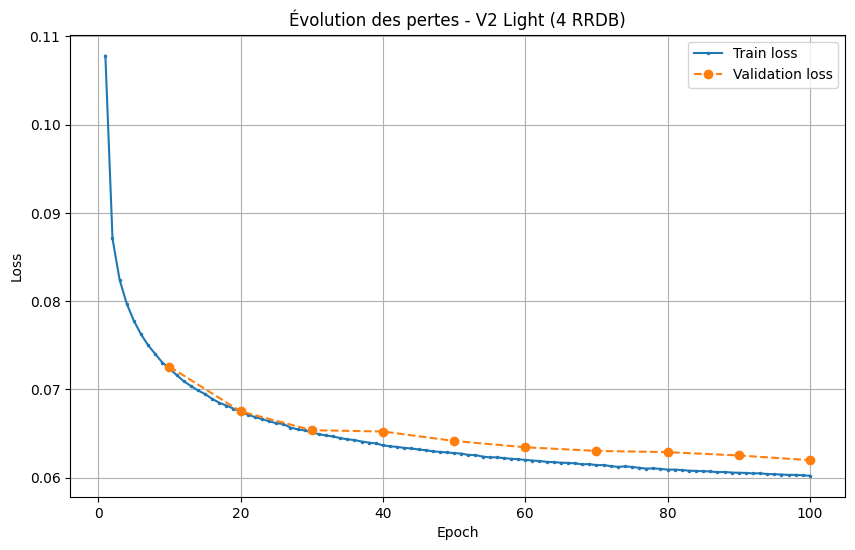

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Chemin du fichier de log
log_file = "/kaggle/working/training_log_v2_light.csv"

# Vérifier que le fichier existe
if not os.path.exists(log_file):
    raise FileNotFoundError(f"Fichier {log_file} introuvable")

# Charger les données
df = pd.read_csv(log_file)

# Afficher un aperçu
print("Colonnes disponibles :", list(df.columns))
print(df.head())

# Créer la figure
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['train_loss'], label='Train loss', marker='.', markersize=3)

# La validation loss n'est présente que toutes les 10 époques
val_data = df[df['val_loss'].notna()]
plt.plot(val_data['epoch'], val_data['val_loss'], label='Validation loss', marker='o', linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution des pertes - V2 Light (4 RRDB)')
plt.legend()
plt.grid(True)

# Sauvegarder l'image
output_image = "/kaggle/working/loss_curve_v2_light.png"
plt.savefig(output_image, dpi=150, bbox_inches='tight')
print(f"Courbe sauvegardée sous : {output_image}")

# Afficher le graphique
plt.show()

In [9]:
import shutil
import os

# Source : le dossier extrait par l'archive
src = "/kaggle/input/datasets/fridamag/results-v2light-session2/kaggle/working/checkpoints_v2_light"
# Destination
dst = "/kaggle/working/checkpoints_v2_light"

# Supprimer l'ancien dossier s'il existe (si vous avez déjà lancé un entraînement depuis zéro)
if os.path.exists(dst):
    shutil.rmtree(dst)

# Copier récursivement
shutil.copytree(src, dst)
print("✅ Checkpoints restaurés.")

✅ Checkpoints restaurés.


In [10]:
!ls -la /kaggle/working/checkpoints_v2_light/

total 58812
drwxr-xr-x 2 root root     4096 Mar 31 21:10 .
drwxr-xr-x 7 root root     4096 Mar 31 21:14 ..
-rw-r--r-- 1 root root 15056290 Mar 31 21:10 best_model.pth
-rw-r--r-- 1 root root 45154802 Mar 31 21:10 latest_checkpoint.pth


In [11]:
"""
MEFSR-GAN v2.0 Light (4 RRDB) - Session 3 (époques 101-200)
Reprise automatique depuis le checkpoint de la session 2.
Avec sauvegarde, évaluation intermédiaire et création d'archive ZIP.
"""

import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv
from pytorch_msssim import SSIM
from IPython.display import FileLink

# ===================== IMPORTS DES MODULES PERSO =====================
from create_dataloader import create_dataloaders
from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionAttention, extract_edges_canny
from module3_sr_network import SRNetworkESRGAN

# ===================== ARCHITECTURE v2.0 Light =====================
class MEFSR_GAN_v2(nn.Module):
    def __init__(self, num_mask_blocks=4, num_rrdb_blocks=4):
        super(MEFSR_GAN_v2, self).__init__()
        self.mask_removal = MaskRemovalModule(
            in_channels=3, out_channels=64, num_residual_blocks=num_mask_blocks
        )
        self.edge_fusion = EdgeFusionAttention(feature_channels=64)
        self.sr_network = SRNetworkESRGAN(
            in_channels=64, out_channels=3, num_rrdb_blocks=num_rrdb_blocks
        )

    def forward(self, x):
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused_features = self.edge_fusion(features, edges)
        output = self.sr_network(fused_features)
        return output

# ===================== LOSSES =====================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160,160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160,160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)

    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

# ===================== HYPERPARAMÈTRES =====================
EPOCHS = 200                     # Session 3 : on va jusqu'à 200
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0

LAMBDA_PIXEL = 1.0
LAMBDA_PERCEP = 0.1
LAMBDA_ID = 0.01
LAMBDA_SSIM = 0.1

VALIDATION_EVERY = 10
IDENTITY_EVERY = 1              # FaceNet à chaque époque

MAX_TRAINING_TIME = 12 * 3600   # 12 heures max pour cette session (ajustable)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_ROOT = "/kaggle/working/dataset_processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v2_light"
VISUAL_DIR = "/kaggle/working/training_visuals_v2_light"
LOG_FILE = "/kaggle/working/training_log_v2_light.csv"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("="*60)
print("MEFSR-GAN v2.0 Light - SESSION 3 (époques 101-200)")
print("="*60)
print(f"  - Epochs max : {EPOCHS}")
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - LR : {LR}")
print(f"  - Weight decay : {WEIGHT_DECAY}")
print(f"  - Gradient clipping : {GRAD_CLIP_NORM}")
print(f"  - λ_Pixel : {LAMBDA_PIXEL}")
print(f"  - λ_Percep : {LAMBDA_PERCEP}")
print(f"  - λ_ID : {LAMBDA_ID}")
print(f"  - λ_SSIM : {LAMBDA_SSIM}")
print(f"  - Validation tous les {VALIDATION_EVERY} epochs")
print(f"  - FaceNet à chaque époque")
print("="*60 + "\n")

# ===================== DATALOADERS =====================
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

# ===================== MODÈLE =====================
model = MEFSR_GAN_v2(num_mask_blocks=4, num_rrdb_blocks=4).to(DEVICE)

# ===================== INITIALISATION AVEC V1 (si disponible) =====================
v1_checkpoint = "/kaggle/working/checkpoints_v1_ssim_mae/best_model.pth"
if os.path.exists(v1_checkpoint):
    print("🔄 Chargement des poids V1 pour initialisation...")
    pretrained = torch.load(v1_checkpoint, map_location=DEVICE)
    model.load_state_dict(pretrained, strict=False)
    print("✅ Initialisation avec V1 terminée.")
else:
    print("ℹ️  Fichier V1 non trouvé – initialisation aléatoire.")

# ===================== LOSSES =====================
mse_loss = nn.MSELoss()
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss = IdentityLoss(device=DEVICE)
ssim_loss = SSIMLoss(channel=3).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ===================== REPRISE DEPUIS CHECKPOINT =====================
start_epoch = 0
best_val_loss = float('inf')
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

if os.path.exists(checkpoint_path):
    print("🔄 Chargement du dernier checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"✅ Reprise depuis epoch {start_epoch} | Best val loss : {best_val_loss:.4f}")
else:
    print("🆕 Aucun checkpoint trouvé – démarrage depuis le début.")

# ===================== BATCH FIXE POUR VISUALISATION =====================
val_batch_fixed = None
for inputs, targets in val_loader:
    val_batch_fixed = (inputs[:4].to(DEVICE), targets[:4].to(DEVICE))
    break

def visualize_results(epoch, model, val_batch, save_path):
    try:
        model.eval()
        inputs, targets = val_batch
        with torch.no_grad():
            outputs = model(inputs)
        fig, axes = plt.subplots(4, 3, figsize=(12, 12))
        fig.suptitle(f"MEFSR-GAN v2.0 Light - Epoch {epoch+1}", fontsize=16)
        for i in range(4):
            input_up = F.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy()
            output_img = outputs[i].cpu().permute(1,2,0).numpy()
            target_img = targets[i].cpu().permute(1,2,0).numpy()
            axes[i,0].imshow(np.clip(input_up,0,1))
            axes[i,0].set_title("Input LR")
            axes[i,0].axis('off')
            axes[i,1].imshow(np.clip(output_img,0,1))
            axes[i,1].set_title("Output SR v2.0")
            axes[i,1].axis('off')
            axes[i,2].imshow(np.clip(target_img,0,1))
            axes[i,2].set_title("Target HR")
            axes[i,2].axis('off')
        plt.tight_layout()
        plt.savefig(f"{save_path}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   📸 Visualisation sauvegardée")
    except Exception as e:
        print(f"   ⚠️ Erreur visualisation : {e}")
        plt.close('all')

# ===================== INITIALISATION LOG =====================
# Si le fichier log n'existe pas (cas improbable), on l'initialise.
if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim',
                         'val_loss', 'lr', 'time_hours'])

# ===================== BOUCLE D'ENTRAÎNEMENT =====================
print("\n🚀 DÉBUT ENTRAÎNEMENT V2 LIGHT (SESSION 3)")
print("="*60 + "\n")

training_start_time = time.time()

for epoch in range(start_epoch, EPOCHS):
    elapsed_time = time.time() - training_start_time
    time_hours = elapsed_time / 3600

    if elapsed_time > MAX_TRAINING_TIME:
        print(f"\n⏰ TEMPS LIMITE ATTEINT ({MAX_TRAINING_TIME/3600}h)")
        break

    use_identity = True   # FaceNet toujours actif

    model.train()
    total_loss = total_pixel = total_percep = total_id = total_ssim = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, targets in loop:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)

        loss_pixel = mse_loss(outputs, targets)
        loss_percep = perceptual_loss(outputs, targets)
        loss_ssim = ssim_loss(outputs, targets)
        loss_id = identity_loss(outputs, targets)

        loss = (LAMBDA_PIXEL * loss_pixel +
                LAMBDA_PERCEP * loss_percep +
                LAMBDA_SSIM * loss_ssim +
                LAMBDA_ID * loss_id)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_percep += loss_percep.item()
        total_id += loss_id.item()
        total_ssim += loss_ssim.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    avg_pixel = total_pixel / len(train_loader)
    avg_percep = total_percep / len(train_loader)
    avg_id = total_id / len(train_loader)
    avg_ssim = total_ssim / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} "
          f"(Pixel: {avg_pixel:.4f}, Percep: {avg_percep:.4f}, "
          f"ID: {avg_id:.4f}, SSIM: {avg_ssim:.4f}) - LR: {current_lr:.2e} - Time: {time_hours:.1f}h")

    # ========== VALIDATION ==========
    val_loss_current = None
    if (epoch + 1) % VALIDATION_EVERY == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss_pixel = mse_loss(outputs, targets)
                loss_percep = perceptual_loss(outputs, targets)
                loss_id = identity_loss(outputs, targets)
                loss_ssim = ssim_loss(outputs, targets)
                loss = (LAMBDA_PIXEL * loss_pixel +
                        LAMBDA_PERCEP * loss_percep +
                        LAMBDA_ID * loss_id +
                        LAMBDA_SSIM * loss_ssim)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_loss_current = val_loss
        print(f"   📊 Validation Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print(f"   ✅ Best model saved (loss = {val_loss:.4f})")
        visualize_results(epoch, model, val_batch_fixed, VISUAL_DIR)
        scheduler.step(val_loss)

    # ========== CHECKPOINT ==========
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
    }
    torch.save(checkpoint, checkpoint_path)
    if (epoch + 1) % 2 == 0:
        print(f"   💾 Checkpoint saved (epoch {epoch+1})")

    # ========== LOG ==========
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss, avg_pixel, avg_percep, avg_id, avg_ssim,
                         val_loss_current if val_loss_current else '', current_lr, time_hours])

print("\n" + "="*60)
print("🎉 FIN DE LA SESSION 3")
print("="*60)

# ===================== ÉVALUATION SUR LE TEST (après la session) =====================
print("\n📊 Évaluation du meilleur modèle sur l'ensemble de test...")

# Charger le meilleur modèle (le plus récent)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
else:
    print("⚠️  Aucun best_model.pth trouvé, utilisation du dernier checkpoint.")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        for i in range(inputs.size(0)):
            out_np = outputs[i].cpu().permute(1,2,0).numpy()
            tgt_np = targets[i].cpu().permute(1,2,0).numpy()
            out_np = np.clip(out_np, 0, 1)
            tgt_np = np.clip(tgt_np, 0, 1)
            p = psnr(tgt_np, out_np, data_range=1.0)
            s = ssim(tgt_np, out_np, multichannel=True, channel_axis=-1, data_range=1.0)
            psnr_list.append(p)
            ssim_list.append(s)

print(f"\n✅ RÉSULTATS APRÈS {epoch+1} ÉPOQUES")
print(f"   PSNR moyen sur test : {np.mean(psnr_list):.2f} dB")
print(f"   SSIM moyen sur test : {np.mean(ssim_list):.4f}")

# Sauvegarde des métriques dans un fichier texte pour cette session
with open("/kaggle/working/metrics_session3.txt", "w") as f:
    f.write(f"Epochs réalisées : {epoch+1}\n")
    f.write(f"PSNR : {np.mean(psnr_list):.2f} dB\n")
    f.write(f"SSIM : {np.mean(ssim_list):.4f}\n")
    f.write(f"Best validation loss : {best_val_loss:.4f}\n")

# ===================== CRÉATION D'UNE ARCHIVE ZIP =====================
print("\n📦 Création de l'archive ZIP des résultats...")
items_to_zip = [
    CHECKPOINT_DIR,
    VISUAL_DIR,
    LOG_FILE,
    "/kaggle/working/metrics_session3.txt"
]

existing_items = [item for item in items_to_zip if os.path.exists(item)]

if existing_items:
    archive_name = "results_v2_light_session3.zip"
    cmd = f"zip -r {archive_name} " + " ".join(existing_items)
    os.system(cmd)
    print(f"✅ Archive créée : {archive_name}")
    display(FileLink(archive_name))
else:
    print("⚠️  Aucun fichier à archiver.")

print("\n🎯 SESSION 3 TERMINÉE. L'entraînement est maintenant terminé.")

MEFSR-GAN v2.0 Light - SESSION 3 (époques 101-200)
  - Epochs max : 200
  - Batch size : 16
  - LR : 0.0001
  - Weight decay : 1e-05
  - Gradient clipping : 1.0
  - λ_Pixel : 1.0
  - λ_Percep : 0.1
  - λ_ID : 0.01
  - λ_SSIM : 0.1
  - Validation tous les 10 epochs
  - FaceNet à chaque époque

ℹ️  Fichier V1 non trouvé – initialisation aléatoire.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🔄 Chargement du dernier checkpoint...
✅ Reprise depuis epoch 100 | Best val loss : 0.0620

🚀 DÉBUT ENTRAÎNEMENT V2 LIGHT (SESSION 3)



Epoch 101/200: 100%|██████████| 1234/1234 [05:55<00:00,  3.47it/s, loss=0.0645]


Epoch 101/200 - Loss: 0.0602 (Pixel: 0.0038, Percep: 0.3557, ID: 0.2496, SSIM: 0.1836) - LR: 1.00e-04 - Time: 0.0h


...

Epoch 200/200: 100%|██████████| 1234/1234 [05:54<00:00,  3.48it/s, loss=0.0569]

Epoch 200/200 - Loss: 0.0584 (Pixel: 0.0035, Percep: 0.3486, ID: 0.2348, SSIM: 0.1767) - LR: 1.00e-04 - Time: 9.8h


   📊 Validation Loss: 0.0614
   📸 Visualisation sauvegardée
   💾 Checkpoint saved (epoch 200)

🎉 FIN DE LA SESSION 3

📊 Évaluation du meilleur modèle sur l'ensemble de test...

✅ RÉSULTATS APRÈS 200 ÉPOQUES
   PSNR moyen sur test : 24.82 dB
   SSIM moyen sur test : 0.8128

📦 Création de l'archive ZIP des résultats...
  adding: kaggle/working/checkpoints_v2_light/ (stored 0%)
  adding: kaggle/working/checkpoints_v2_light/latest_checkpoint.pth (deflated 5%)
  adding: kaggle/working/checkpoints_v2_light/best_model.pth (deflated 4%)
  adding: kaggle/working/training_visuals_v2_light/ (stored 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_200.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_190.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_110.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_130.png (deflated 0%)
  adding: kaggle/working/training_visuals_v2_light/epoch_160.png (deflated 0%)
  addi

/kaggle/working/results_v2_light_session3.zip


🎯 SESSION 3 TERMINÉE. L'entraînement est maintenant terminé.


Nombre d'époques enregistrées : 100
Colonnes disponibles : ['epoch', 'train_loss', 'pixel', 'percep', 'id', 'ssim', 'val_loss', 'lr', 'time_hours']
Dernières lignes :
    epoch  train_loss     pixel    percep        id      ssim  val_loss  \
95    196    0.058462  0.003512  0.348880  0.235331  0.177081       NaN   
96    197    0.058426  0.003510  0.348739  0.235029  0.176927       NaN   
97    198    0.058429  0.003511  0.348766  0.235361  0.176877       NaN   
98    199    0.058366  0.003477  0.348665  0.235363  0.176689       NaN   
99    200    0.058364  0.003485  0.348566  0.234826  0.176737  0.061445   

        lr  time_hours  
95  0.0001    9.414046  
96  0.0001    9.512473  
97  0.0001    9.610847  
98  0.0001    9.709347  
99  0.0001    9.807858  
Courbe sauvegardée sous : /kaggle/working/loss_curve_v2_light_200epochs.png


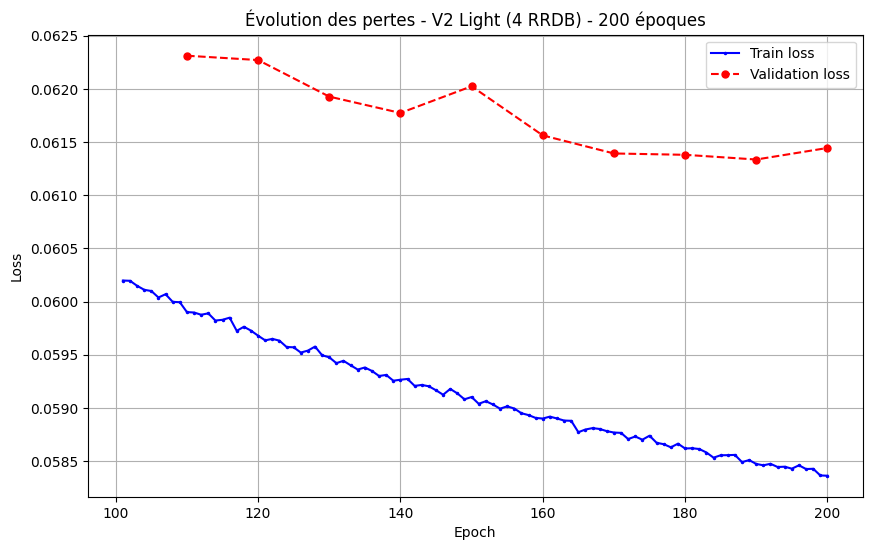

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Chemin du fichier de log
log_file = "/kaggle/working/training_log_v2_light.csv"

# Vérifier que le fichier existe
if not os.path.exists(log_file):
    raise FileNotFoundError(f"Fichier {log_file} introuvable")

# Charger les données
df = pd.read_csv(log_file)

print(f"Nombre d'époques enregistrées : {len(df)}")
print("Colonnes disponibles :", list(df.columns))
print("Dernières lignes :")
print(df.tail())

# Créer la figure
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['train_loss'], label='Train loss', marker='.', markersize=3, color='blue')
val_data = df[df['val_loss'].notna()]
plt.plot(val_data['epoch'], val_data['val_loss'], label='Validation loss', marker='o', linestyle='--', color='red', markersize=5)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution des pertes - V2 Light (4 RRDB) - 200 époques')
plt.legend()
plt.grid(True)

# Sauvegarder l'image
output_image = "/kaggle/working/loss_curve_v2_light_200epochs.png"
plt.savefig(output_image, dpi=150, bbox_inches='tight')
print(f"Courbe sauvegardée sous : {output_image}")

# Afficher le graphique
plt.show()